# Machine Learning Techniques: A Practical Guide

This notebook provides hands-on exercises covering key machine learning preprocessing and modeling techniques:
1. Data Imputation
2. Feature Engineering (Numeric & Categorical Transformations)
3. Regularization
4. Feature Selection
5. Classes Rebalancing
6. Ensemble Methods
7. Probability Calibration
8. Model Depreciation (Drift Detection)

Author: Michał Woźniak

## Technical Setup: Running This Notebook Locally with `uv`

### Prerequisites
- Ensure you have `uv` installed on your system. If not, install it following the instructions at [https://github.com/astral-sh/uv](https://github.com/astral-sh/uv)

### Step 1: Initialize a New Project
Navigate to your working directory and initialize a new Python project:
```bash
# Navigate to your project directory
cd /path/to/your/project

# Initialize uv project (if not already initialized)
uv init

# Or if you want to specify Python version
uv init --python 3.11
```

### Step 2: Install Required Dependencies
Install all necessary packages for this notebook:
```bash
# Install core data science packages
uv add numpy pandas scikit-learn scipy

# Install visualization libraries
uv add matplotlib seaborn

# Install imbalanced-learn (for resampling techniques)
uv add imbalanced-learn

# Install Jupyter notebook
uv add jupyter ipykernel

# Alternative: Install all at once
uv add numpy pandas scikit-learn scipy matplotlib seaborn imbalanced-learn jupyter ipykernel
```

### Step 3: Activate the Environment and Start Jupyter
```bash
# Activate the virtual environment (uv handles this automatically)
# Start Jupyter notebook
uv run jupyter notebook

# Or use Jupyter Lab
uv run jupyter lab
```

### Step 4: Open This Notebook
Once Jupyter starts, navigate to `MLTechniques.ipynb` and open it.

### Required Packages Summary
- **numpy** (≥1.21.0): Numerical computations and array operations
- **pandas** (≥1.3.0): Data manipulation and analysis
- **scikit-learn** (≥1.0.0): Machine learning algorithms and utilities
- **scipy** (≥1.7.0): Scientific computing (statistical tests, distance metrics)
- **imbalanced-learn** (≥0.12.0): Resampling techniques for imbalanced datasets (SMOTE, Tomek Links, etc.)
- **matplotlib** (≥3.4.0): Basic plotting and visualization
- **seaborn** (≥0.11.0): Statistical data visualization
- **jupyter**: Jupyter notebook interface
- **ipykernel**: Jupyter kernel for Python

### Troubleshooting
- If you encounter import errors, ensure all packages are installed: `uv pip list`
- To update packages: `uv add --upgrade package_name`
- To see your Python version: `uv run python --version`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


# 1. Data Imputation

When working with real data you will always encounter the problem of **missing values**. Causes include: data does not exist, hardware/software/human error, data was deleted, etc.

## Types of Missing Data

| Type | Name | Description |
|------|------|-------------|
| **MCAR** | Missing Completely At Random | Missingness is unrelated to observed and unobserved features |
| **MAR** | Missing At Random | Missingness is related to observed features only |
| **NMAR** | Not Missing At Random | Missingness is related to unobserved features (and possibly observed features) |

## Techniques for dealing with missing values:
- **Do nothing**: some ML algorithms handle missing values automatically
- **Remove columns**: when variable has >10% missing and is not crucial
- **Remove rows**: avoid if possible, especially with small datasets
- **Imputation**: fill in missing values using univariate or multivariate techniques

## 1.1 Creating a Dataset with Missing Values

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df_full_housing = housing.frame.copy()
X_full = housing.data.copy()
y_full = housing.target.copy()

# Subsample for imputation exercises (KNN/MICE are expensive on large datasets)
df = df_full_housing.sample(n=2000, random_state=42).reset_index(drop=True)

# Introduce missing values of different types
rng = np.random.default_rng(42)
df_missing = df.copy()

# MCAR: randomly remove 5% of MedInc values
mcar_mask = rng.random(len(df)) < 0.05
df_missing.loc[mcar_mask, 'MedInc'] = np.nan

# MAR: remove AveRooms when Population > 2000
mar_mask = (df_missing['Population'] > 2000) & (rng.random(len(df)) < 0.3)
df_missing.loc[mar_mask, 'AveRooms'] = np.nan

# NMAR: remove HouseAge for older houses
nmar_mask = (df_missing['HouseAge'] > 40) & (rng.random(len(df)) < 0.4)
df_missing.loc[nmar_mask, 'HouseAge'] = np.nan

print("Missing values summary:")
missing = df_missing.isnull().sum()
pct = (100 * missing / len(df_missing)).round(2)
print(pd.DataFrame({'Count': missing, 'Percent': pct})[missing > 0])

Missing values summary:
          Count  Percent
MedInc       91     4.55
HouseAge    163     8.15
AveRooms    102     5.10


## 1.2 Visualizing Missing Data

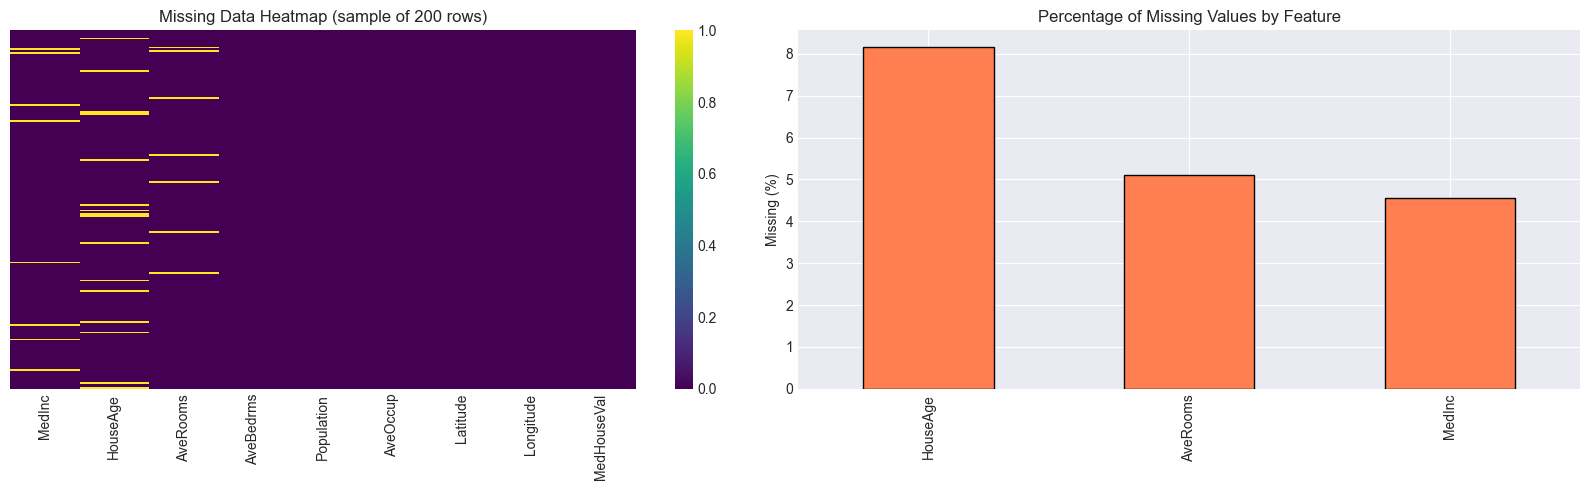

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sample = df_missing.sample(200, random_state=42).sort_index()
sns.heatmap(sample.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Data Heatmap (sample of 200 rows)')

missing_pct = (df_missing.isnull().sum() / len(df_missing) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
missing_pct.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Percentage of Missing Values by Feature')
axes[1].set_ylabel('Missing (%)')

plt.tight_layout()
plt.show()

## 1.3 Removing Missing Data

In [4]:
print("Original shape:", df_missing.shape)

# Drop columns with > 10% missing
threshold = 0.10
cols_to_drop = df_missing.columns[df_missing.isnull().mean() > threshold]
print(f"Columns with >{threshold*100:.0f}% missing: {list(cols_to_drop)}")

df_dropped_cols = df_missing.drop(columns=cols_to_drop)
print(f"Shape after dropping columns: {df_dropped_cols.shape}")

# Drop rows with any missing value
df_dropped_rows = df_missing.dropna()
print(f"Shape after dropping rows: {df_dropped_rows.shape}")
print(f"Rows lost: {len(df_missing) - len(df_dropped_rows)} ({(1 - len(df_dropped_rows)/len(df_missing))*100:.1f}%)")

Original shape: (2000, 9)
Columns with >10% missing: []
Shape after dropping columns: (2000, 9)
Shape after dropping rows: (1652, 9)
Rows lost: 348 (17.4%)


## 1.4 Univariate Imputation (Single Feature)

Uses information from only one column at a time.

- **Continuous variables**: constant (e.g. 0), mean, median, mode, random value from distribution
- **Categorical variables**: new "missing" category, mode, random replacement
- **Time series**: last/next observed value, linear/polynomial/spline interpolation

In [5]:
from sklearn.impute import SimpleImputer

# Constant imputation
imp_constant = SimpleImputer(strategy='constant', fill_value=0)
df_const = df_missing.copy()
df_const['MedInc'] = imp_constant.fit_transform(df_missing[['MedInc']])

# Mean imputation
imp_mean = SimpleImputer(strategy='mean')
df_mean = df_missing.copy()
df_mean['MedInc'] = imp_mean.fit_transform(df_missing[['MedInc']])

# Median imputation
imp_median = SimpleImputer(strategy='median')
df_median = df_missing.copy()
df_median['MedInc'] = imp_median.fit_transform(df_missing[['MedInc']])

# Most frequent (mode) imputation
imp_mode = SimpleImputer(strategy='most_frequent')
df_mode = df_missing.copy()
df_mode['MedInc'] = imp_mode.fit_transform(df_missing[['MedInc']])

print("SimpleImputer strategies: constant, mean, median, most_frequent")
print(f"  Mean fill:   {imp_mean.statistics_[0]:.4f}")
print(f"  Median fill: {imp_median.statistics_[0]:.4f}")

SimpleImputer strategies: constant, mean, median, most_frequent
  Mean fill:   3.8485
  Median fill: 3.4600


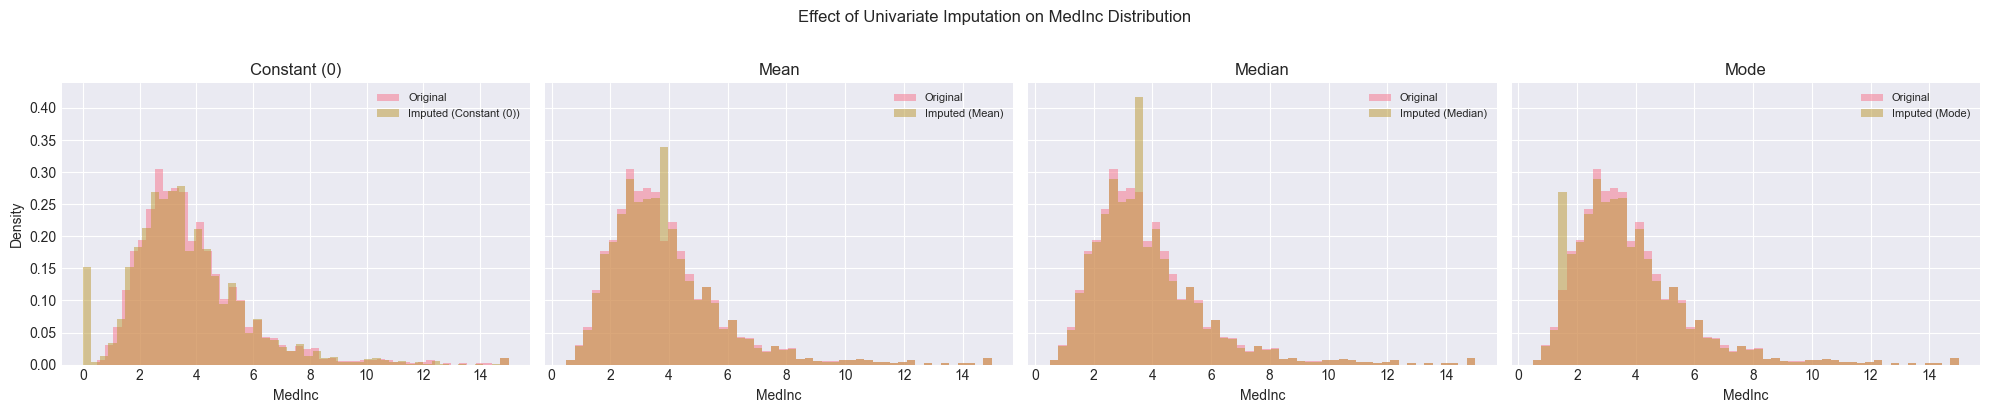

In [6]:
# Visualize the effect of different univariate strategies
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

strategies = [("Constant (0)", df_const), ("Mean", df_mean), ("Median", df_median), ("Mode", df_mode)]
for ax, (name, frame) in zip(axes, strategies):
    ax.hist(df['MedInc'], bins=50, alpha=0.5, label='Original', density=True)
    ax.hist(frame['MedInc'], bins=50, alpha=0.5, label=f'Imputed ({name})', density=True)
    ax.set_title(name)
    ax.legend(fontsize=8)
    ax.set_xlabel('MedInc')

axes[0].set_ylabel('Density')
plt.suptitle('Effect of Univariate Imputation on MedInc Distribution', y=1.02)
plt.tight_layout()
plt.show()

### Missing Indicator

Sometimes the fact that a value was missing carries information — add a binary indicator.

In [7]:
from sklearn.impute import MissingIndicator

indicator = MissingIndicator(features='missing-only')
missing_flags = indicator.fit_transform(df_missing)
print(f"Features with indicators: {df_missing.columns[indicator.features_].tolist()}")

# Combine imputed data with missing indicators
imp = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imp.fit_transform(df_missing), columns=df_missing.columns)
for i, col in enumerate(df_missing.columns[indicator.features_]):
    df_imputed[f'{col}_was_missing'] = missing_flags[:, i].astype(int)

print(f"Shape with indicators: {df_imputed.shape}")
print(df_imputed.head())

Features with indicators: ['MedInc', 'HouseAge', 'AveRooms']
Shape with indicators: (2000, 12)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  1.6812      25.0  4.192201   1.022284      1392.0  3.877437     36.06   
1  2.5313      30.0  5.039384   1.193493      1565.0  2.679795     35.14   
2  3.4801      52.0  3.977155   1.185877      1310.0  1.360332     37.80   
3  5.7376      17.0  6.163636   1.020202      1705.0  3.444444     34.28   
4  3.7250      34.0  5.492991   1.028037      1063.0  2.483645     36.62   

   Longitude  MedHouseVal  MedInc_was_missing  HouseAge_was_missing  \
0    -119.01      0.47700                   0                     0   
1    -119.46      0.45800                   0                     0   
2    -122.44      5.00001                   0                     0   
3    -118.72      2.18600                   0                     0   
4    -121.93      2.78000                   0                     0   

   AveRooms_was_missi

## 1.5 Multivariate Imputation (Multiple Features)

Uses information from all other features to estimate missing values.

- **KNN Imputer**: uses K-nearest neighbors to impute
- **Iterative Imputer (MICE)**: Multivariate Imputation by Chained Equations

In [8]:
from sklearn.impute import KNNImputer

for k in [3, 5, 10]:
    knn_imp = KNNImputer(n_neighbors=k, weights='uniform')
    df_knn = pd.DataFrame(knn_imp.fit_transform(df_missing), columns=df_missing.columns)
    mae = np.abs(df['MedInc'][mcar_mask] - df_knn['MedInc'][mcar_mask]).mean()
    print(f"KNN (k={k:>2d}, uniform):  MAE on MedInc MCAR = {mae:.4f}")

knn_imp_dist = KNNImputer(n_neighbors=5, weights='distance')
df_knn_dist = pd.DataFrame(knn_imp_dist.fit_transform(df_missing), columns=df_missing.columns)
mae = np.abs(df['MedInc'][mcar_mask] - df_knn_dist['MedInc'][mcar_mask]).mean()
print(f"KNN (k= 5, distance): MAE on MedInc MCAR = {mae:.4f}")

KNN (k= 3, uniform):  MAE on MedInc MCAR = 1.5171
KNN (k= 5, uniform):  MAE on MedInc MCAR = 1.4653
KNN (k=10, uniform):  MAE on MedInc MCAR = 1.3619
KNN (k= 5, distance): MAE on MedInc MCAR = 1.4768


In [9]:
from sklearn.experimental import enable_iterative_imputer  # required!
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

estimators = {
    'BayesianRidge': BayesianRidge(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=10, max_depth=5, random_state=42),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=10, max_depth=5, random_state=42),
}

for name, estimator in estimators.items():
    mice_imp = IterativeImputer(estimator=estimator, max_iter=10, random_state=42)
    df_mice = pd.DataFrame(mice_imp.fit_transform(df_missing), columns=df_missing.columns)
    mae = np.abs(df['MedInc'][mcar_mask] - df_mice['MedInc'][mcar_mask]).mean()
    print(f"MICE ({name:>15s}): MAE on MedInc MCAR = {mae:.4f}")

MICE (  BayesianRidge): MAE on MedInc MCAR = 0.6286
MICE (          Ridge): MAE on MedInc MCAR = 0.6276
MICE (   RandomForest): MAE on MedInc MCAR = 0.6603
MICE (     ExtraTrees): MAE on MedInc MCAR = 0.7075


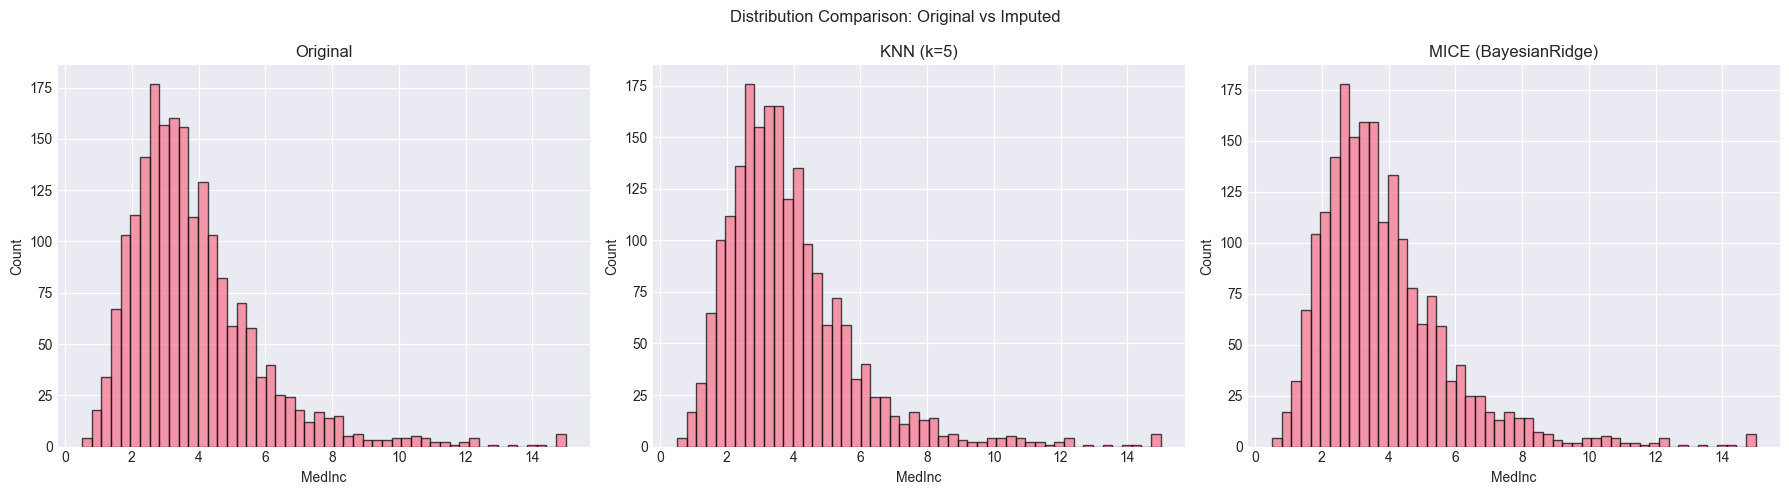

In [10]:
# Visual comparison: Original vs KNN vs MICE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

knn5 = KNNImputer(n_neighbors=5, weights='distance')
df_knn5 = pd.DataFrame(knn5.fit_transform(df_missing), columns=df_missing.columns)

mice = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)
df_mice_final = pd.DataFrame(mice.fit_transform(df_missing), columns=df_missing.columns)

for ax, (name, frame) in zip(axes, [("Original", df), ("KNN (k=5)", df_knn5), ("MICE (BayesianRidge)", df_mice_final)]):
    ax.hist(frame['MedInc'], bins=50, alpha=0.7, edgecolor='black')
    ax.set_title(name)
    ax.set_xlabel('MedInc')
    ax.set_ylabel('Count')

plt.suptitle('Distribution Comparison: Original vs Imputed')
plt.tight_layout()
plt.show()

## 1.6 Imputation in a Pipeline (Preventing Leakage!)

**Critical**: imputation must be fitted on training data only, then applied to test data.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_miss = df_missing.drop(columns=['MedHouseVal'])
y_cls = (df['MedHouseVal'] > df['MedHouseVal'].median()).astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X_miss, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

pipes = {
    "Median": Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    "KNN": Pipeline([('imp', KNNImputer(n_neighbors=5)), ('scl', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    "MICE": Pipeline([('imp', IterativeImputer(random_state=42, max_iter=10)), ('scl', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
}

for name, pipe in pipes.items():
    scores = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring='accuracy')
    print(f"{name:>8s} Imputer -> CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

  Median Imputer -> CV Accuracy: 0.8456 (+/- 0.0209)
     KNN Imputer -> CV Accuracy: 0.8450 (+/- 0.0186)
    MICE Imputer -> CV Accuracy: 0.8469 (+/- 0.0147)


## 1.7 Handling Categorical Missing Values

In [12]:
from sklearn.compose import ColumnTransformer

cat_data = pd.DataFrame({
    'Color': np.random.choice(['Red', 'Blue', 'Green', None], size=200, p=[0.3, 0.3, 0.3, 0.1]),
    'Size': np.random.choice(['S', 'M', 'L', None], size=200, p=[0.25, 0.35, 0.25, 0.15]),
    'Weight': rng.normal(50, 10, 200)
})
cat_data.loc[rng.random(200) < 0.08, 'Weight'] = np.nan

# Strategy 1: most_frequent for categorical, median for numeric
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), ['Weight']),
    ('cat', SimpleImputer(strategy='most_frequent'), ['Color', 'Size']),
])
result = preprocessor.fit_transform(cat_data)
print("ColumnTransformer imputation (median + most_frequent):")
print(pd.DataFrame(result, columns=['Weight', 'Color', 'Size']).head(10))

# Strategy 2: new "missing" category
cat_filled = cat_data.copy()
for col in ['Color', 'Size']:
    cat_filled[col] = cat_filled[col].fillna('missing')
print("\nValue counts after adding 'missing' category:")
print(cat_filled['Color'].value_counts())

ColumnTransformer imputation (median + most_frequent):
      Weight  Color Size
0   50.52005   Blue    L
1  54.826355    Red    S
2   43.92471  Green    S
3  33.509337   Blue    M
4  47.125289    Red    L
5   63.24737    Red    S
6   54.60742    Red    S
7  70.178094  Green    L
8  51.772301  Green    S
9  74.478028  Green    S

Value counts after adding 'missing' category:
Color
Red        66
Green      59
Blue       56
missing    19
Name: count, dtype: int64


## 1.8 Time Series Imputation

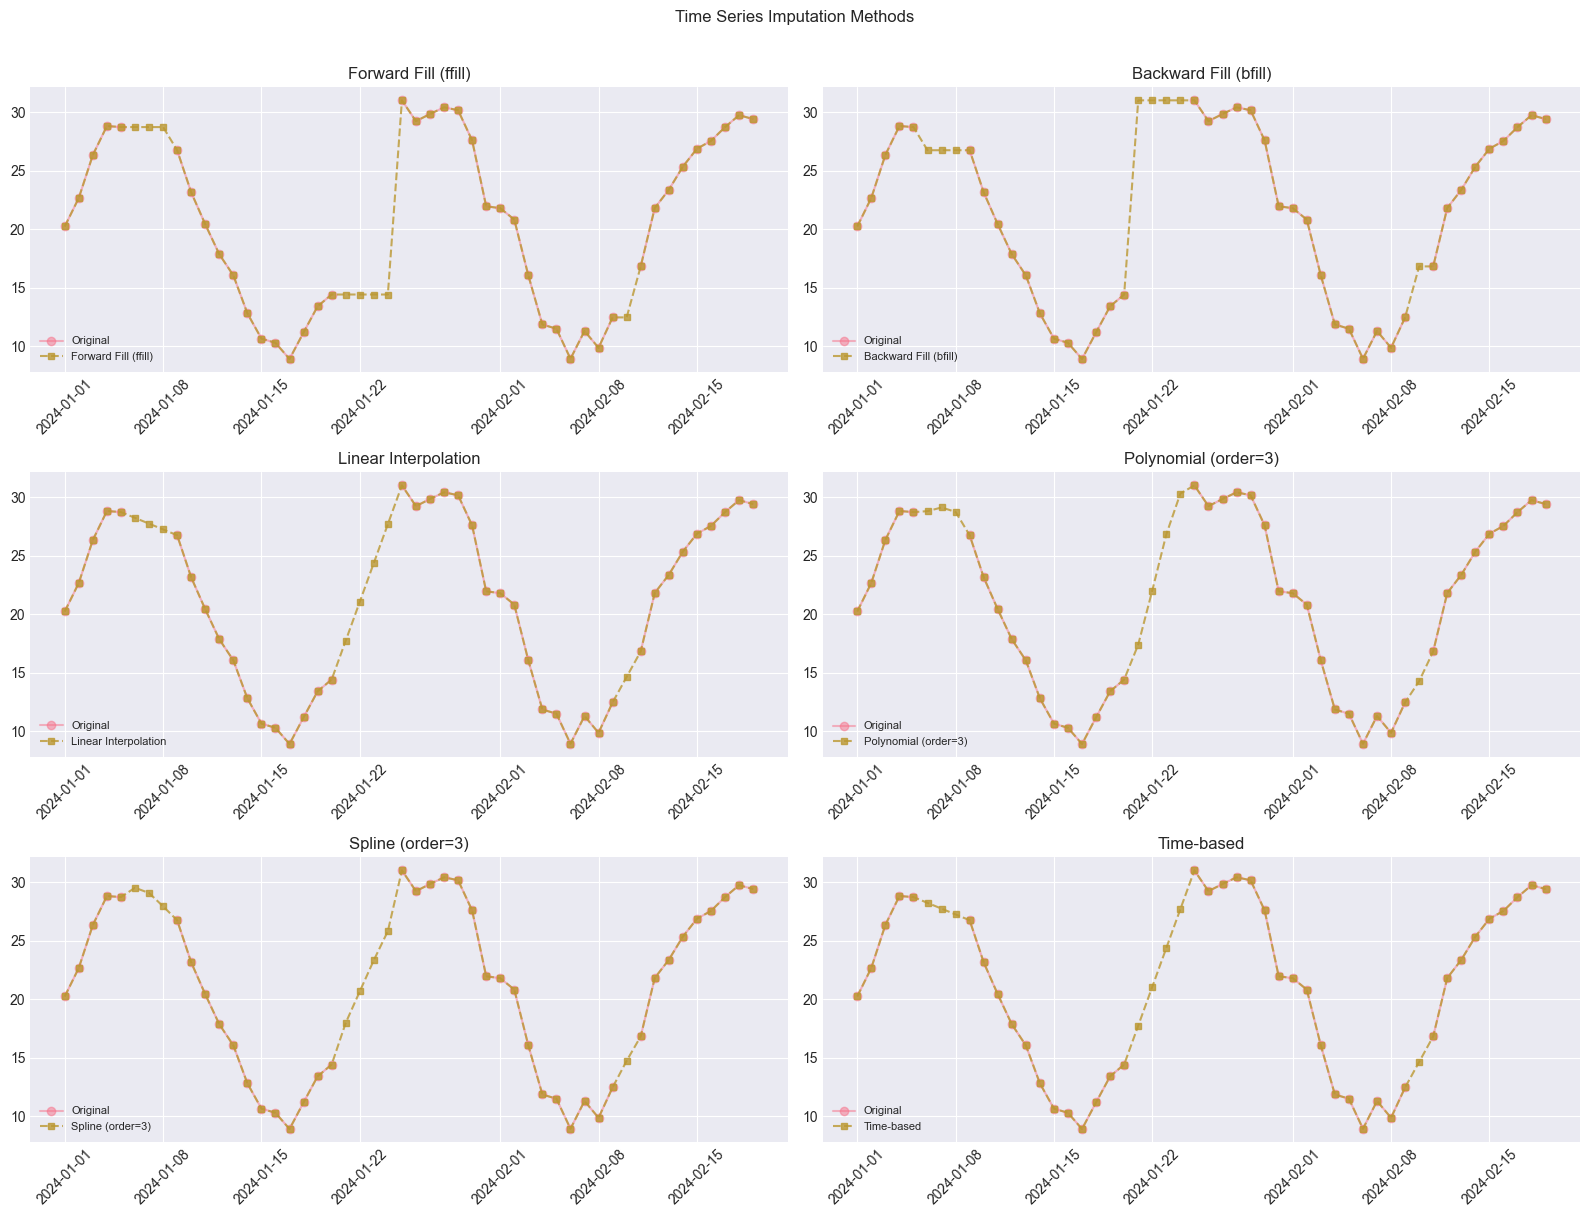

In [13]:
dates = pd.date_range('2024-01-01', periods=50, freq='D')
values = np.sin(np.arange(50) * 0.3) * 10 + rng.normal(0, 1, 50) + 20
ts = pd.Series(values, index=dates)
ts.iloc[5:8] = np.nan
ts.iloc[20:24] = np.nan
ts.iloc[40] = np.nan

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
methods = {
    'Forward Fill (ffill)': ts.ffill(),
    'Backward Fill (bfill)': ts.bfill(),
    'Linear Interpolation': ts.interpolate(method='linear'),
    'Polynomial (order=3)': ts.interpolate(method='polynomial', order=3),
    'Spline (order=3)': ts.interpolate(method='spline', order=3),
    'Time-based': ts.interpolate(method='time'),
}

for ax, (name, filled) in zip(axes.flat, methods.items()):
    ax.plot(ts.index, ts.values, 'o-', label='Original', alpha=0.5)
    ax.plot(filled.index, filled.values, 's--', label=name, alpha=0.8, markersize=4)
    ax.set_title(name)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Time Series Imputation Methods', y=1.01)
plt.tight_layout()
plt.show()

# 2. Feature Engineering

Feature engineering is a **key stage of modeling** — the quality of the model depends on correct preprocessing. It happens in two moments:

1. **During ETL**: analytical engineering with domain knowledge (aggregations, statistics)
2. **After ETL**: creating additional variables or transforming existing ones to improve predictive power

**Important**: each transformation must be **fitted on training data only**, then applied to test data.

## 2.1 Numeric Variable Transformations

In [14]:
from sklearn.model_selection import train_test_split
X = X_full.copy()
y = y_full.copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
feature_names = X.columns
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (16512, 8), Test: (4128, 8)


### Min-Max Scaler
$$z = \frac{x - \min(x)}{\max(x) - \min(x)}$$
**Recommendation**: when the feature is more-or-less uniformly distributed across a fixed range.

In [15]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
X_train_mm = minmax.fit_transform(X_train)
X_test_mm = minmax.transform(X_test)

# Custom range
minmax_custom = MinMaxScaler(feature_range=(-1, 1))
X_train_mm_c = minmax_custom.fit_transform(X_train)

print("Min-Max (0,1) — Train min:", X_train_mm.min(axis=0).round(3))
print("Min-Max (0,1) — Train max:", X_train_mm.max(axis=0).round(3))
print("Min-Max (0,1) — Test max: ", X_test_mm.max(axis=0).round(3), "(can exceed 1 on test!)")

Min-Max (0,1) — Train min: [0. 0. 0. 0. 0. 0. 0. 0.]
Min-Max (0,1) — Train max: [1. 1. 1. 1. 1. 1. 1. 1.]
Min-Max (0,1) — Test max:  [1.    1.    0.934 1.333 0.452 0.066 0.985 0.973] (can exceed 1 on test!)


### Standard Scaler (Z-Score)
$$z = \frac{x - \mu}{\sigma}$$
**Recommendation**: when the feature distribution does not contain extreme outliers.

In [16]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

print("Train mean:", X_train_std.mean(axis=0).round(6))
print("Train std: ", X_train_std.std(axis=0).round(6))
print("Learned means:", std_scaler.mean_.round(4))
print("Learned stds: ", std_scaler.scale_.round(4))

Train mean: [-0. -0.  0. -0.  0.  0.  0.  0.]
Train std:  [1. 1. 1. 1. 1. 1. 1. 1.]
Learned means: [ 3.880800e+00  2.860830e+01  5.435200e+00  1.096700e+00  1.426453e+03
  3.097000e+00  3.564310e+01 -1.195823e+02]
Learned stds:  [1.9042000e+00 1.2602100e+01 2.3873000e+00 4.3320000e-01 1.1370219e+03
 1.1578400e+01 2.1366000e+00 2.0056000e+00]


### Robust Scaler
Uses median and IQR — robust to outliers.

In [17]:
from sklearn.preprocessing import RobustScaler

robust = RobustScaler()
X_train_rob = robust.fit_transform(X_train)
print("Centers (medians):", robust.center_.round(4))
print("Scales (IQR):     ", robust.scale_.round(4))

Centers (medians): [ 3.5458e+00  2.9000e+01  5.2359e+00  1.0493e+00  1.1670e+03  2.8172e+00
  3.4260e+01 -1.1851e+02]
Scales (IQR):      [2.2065e+00 1.9000e+01 1.6090e+00 9.3800e-02 9.3700e+02 8.5120e-01
 3.7900e+00 3.8000e+00]


### Clipping / Winsorization
If $x > \text{max}$, then $z = \text{max}$; if $x < \text{min}$, then $z = \text{min}$.

**Recommendation**: when the feature contains extreme outliers.

Original range: [3, 35682]
Clipped [1%, 99%]: [88, 5799]


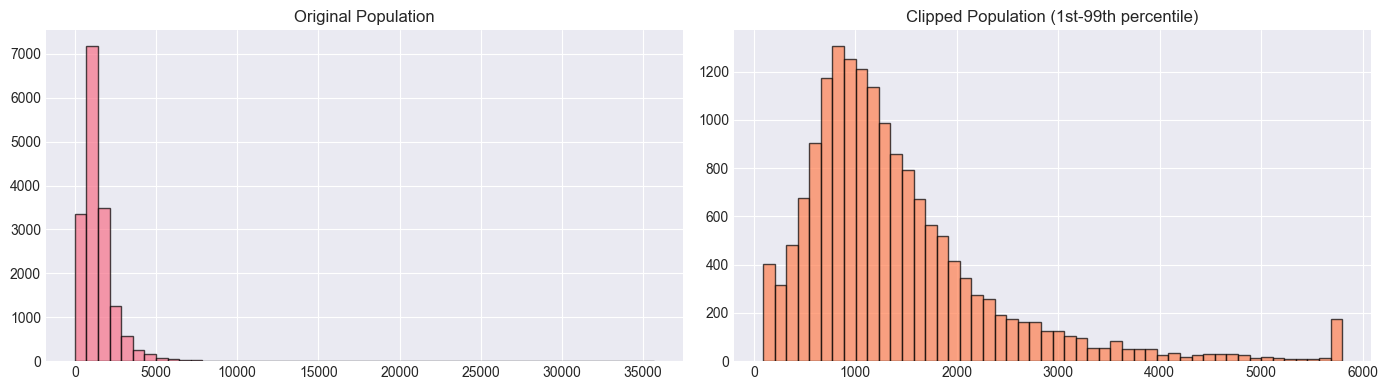

In [18]:
feature = X_train['Population'].values
q01, q99 = np.percentile(feature, [1, 99])
clipped = np.clip(feature, q01, q99)

print(f"Original range: [{feature.min():.0f}, {feature.max():.0f}]")
print(f"Clipped [1%, 99%]: [{q01:.0f}, {q99:.0f}]")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(feature, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Original Population')
axes[1].hist(clipped, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Clipped Population (1st-99th percentile)')
plt.tight_layout()
plt.show()

### Log Scaling
$$z = \log(x)$$
**Recommendation**: when the feature conforms to the power law (right-skewed).

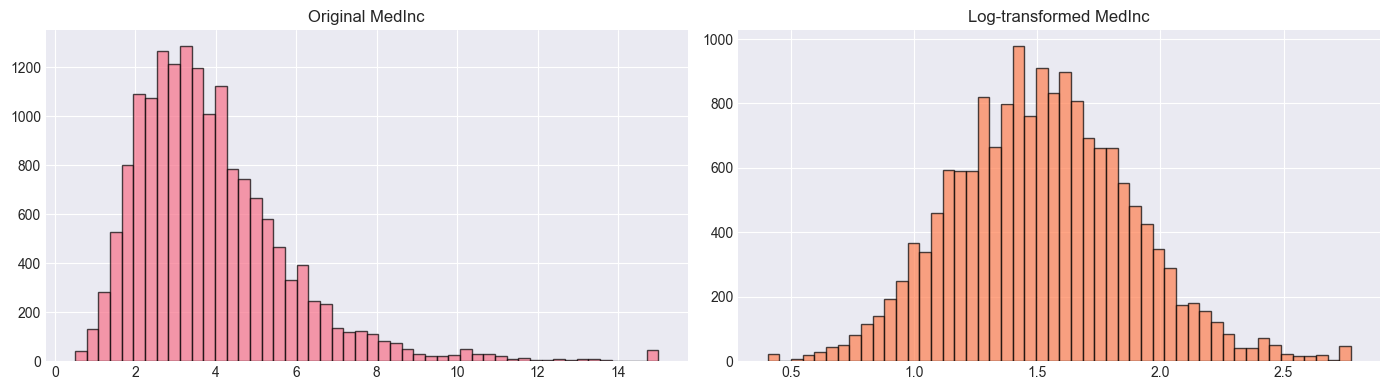

In [19]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log1p, inverse_func=np.expm1, validate=False)
X_train_log = log_transformer.fit_transform(X_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(X_train.iloc[:, 0], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Original {X.columns[0]}')
axes[1].hist(X_train_log.iloc[:, 0] if hasattr(X_train_log, 'iloc') else X_train_log[:, 0], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title(f'Log-transformed {X.columns[0]}')
plt.tight_layout()
plt.show()

### Quantile Transformer
Maps data to a uniform distribution (0-1) or normal distribution.

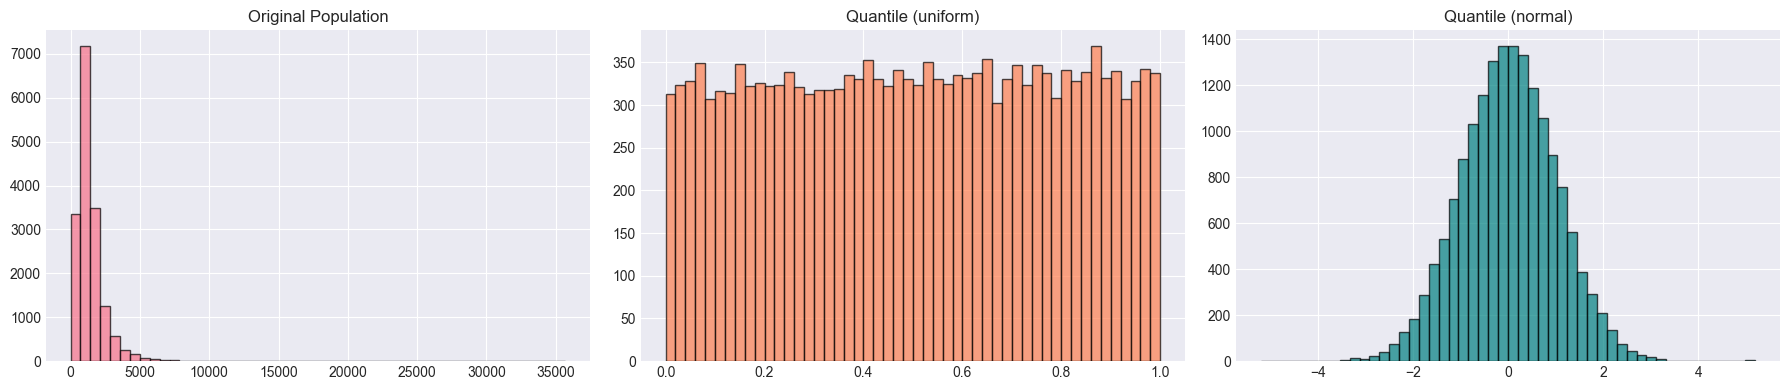

In [20]:
from sklearn.preprocessing import QuantileTransformer

qt_uniform = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
qt_normal = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)

X_train_qt_u = qt_uniform.fit_transform(X_train)
X_train_qt_n = qt_normal.fit_transform(X_train)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
idx = 4  # AveOccup (very skewed)
axes[0].hist(X_train.iloc[:, idx], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Original {X.columns[idx]}')
axes[1].hist(X_train_qt_u[:, idx], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Quantile (uniform)')
axes[2].hist(X_train_qt_n[:, idx], bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[2].set_title('Quantile (normal)')
plt.tight_layout()
plt.show()

### Power Transformer (Yeo-Johnson, Box-Cox)
Maps data to as close to Gaussian as possible.
- **Box-Cox**: requires strictly positive data
- **Yeo-Johnson**: works with any data

Yeo-Johnson lambdas: [-0.1898  0.8049 -0.5426 -4.3022  0.2331 -0.912  -5.3034  8.0186]

Box-Cox: 7 of 8 features are strictly positive and non-constant
Box-Cox lambdas: [ 0.0975  0.8064 -0.2895 -1.5761  0.2353 -0.4849 -5.1439]


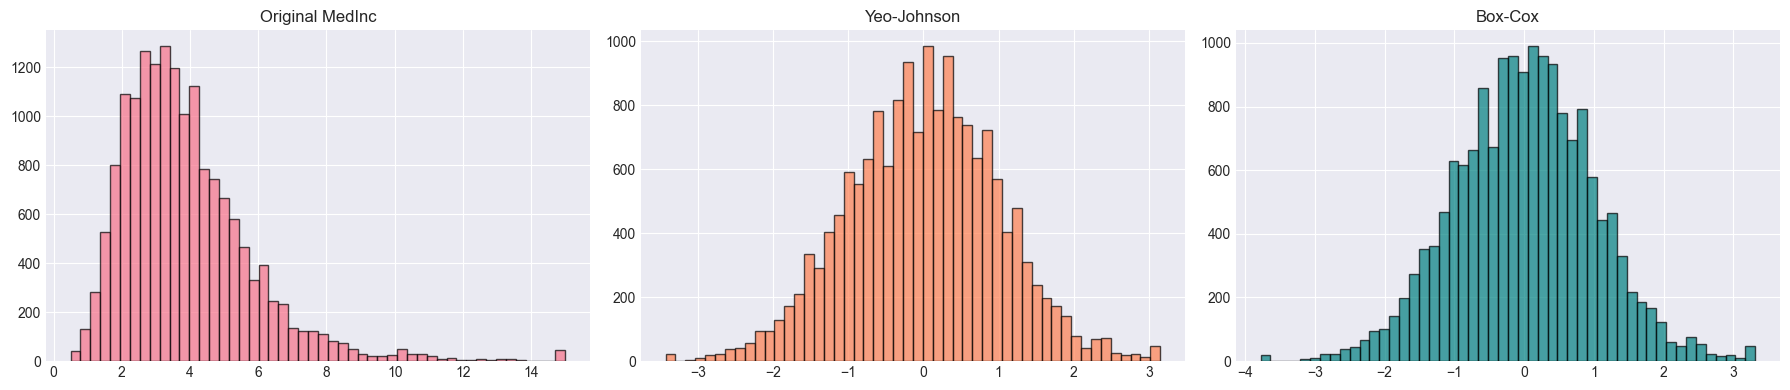

In [21]:
from sklearn.preprocessing import PowerTransformer

# Yeo-Johnson works with any data
pt_yj = PowerTransformer(method='yeo-johnson', standardize=True)
X_train_yj = pt_yj.fit_transform(X_train)
print("Yeo-Johnson lambdas:", pt_yj.lambdas_.round(4))

# Box-Cox requires strictly positive and non-constant data
# Select only columns that are strictly positive and have variance
X_train_pos = X_train.copy()
valid_cols = (X_train_pos.min() > 0) & (X_train_pos.nunique() > 1)
X_bc_input = X_train_pos.loc[:, valid_cols]
print(f"\nBox-Cox: {valid_cols.sum()} of {len(valid_cols)} features are strictly positive and non-constant")

pt_bc = PowerTransformer(method='box-cox', standardize=True)
X_train_bc = pt_bc.fit_transform(X_bc_input)
print("Box-Cox lambdas:", pt_bc.lambdas_.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
# Use first feature for comparison
axes[0].hist(X_train.iloc[:, 0], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Original {X.columns[0]}')
axes[1].hist(X_train_yj[:, 0], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Yeo-Johnson')
axes[2].hist(X_train_bc[:, 0], bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[2].set_title('Box-Cox')
plt.tight_layout()
plt.show()

### Bucketing / Discretization
Dividing continuous variables into discrete bins. Strategies: uniform, quantile, kmeans.

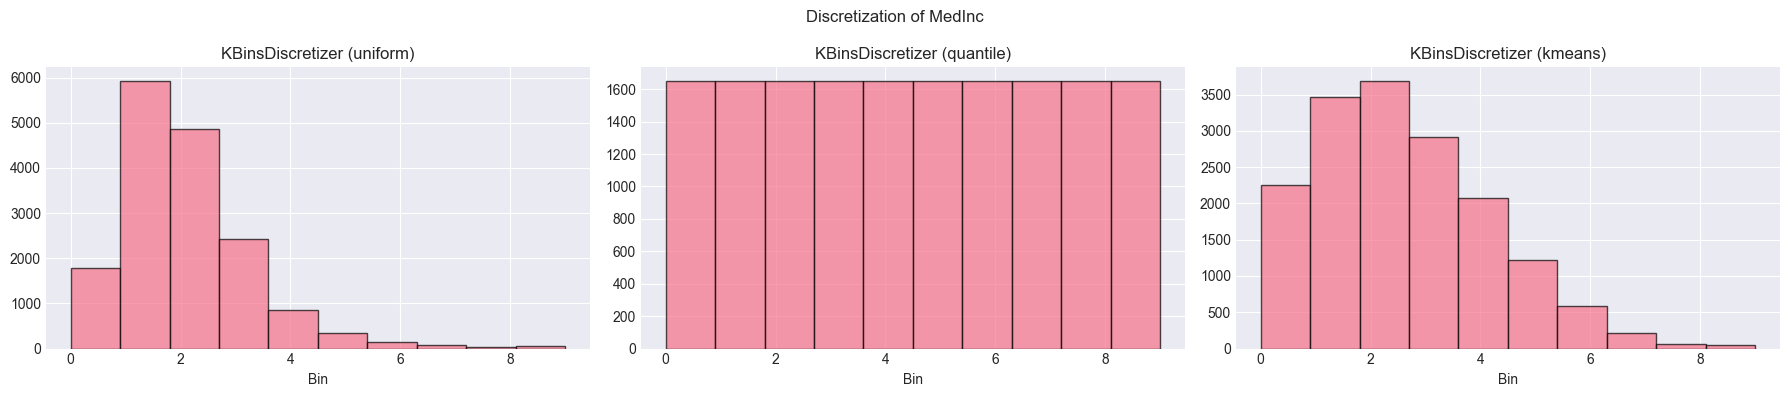

In [22]:
from sklearn.preprocessing import KBinsDiscretizer

feature = X_train[['MedInc']]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, strategy in zip(axes, ['uniform', 'quantile', 'kmeans']):
    kbd = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy=strategy)
    binned = kbd.fit_transform(feature)
    ax.hist(binned, bins=10, edgecolor='black', alpha=0.7)
    ax.set_title(f'KBinsDiscretizer ({strategy})')
    ax.set_xlabel('Bin')

plt.suptitle('Discretization of MedInc')
plt.tight_layout()
plt.show()

### Polynomial and Spline Transformations

In [23]:
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(X_train[['MedInc', 'AveRooms']])
print(f"Polynomial (degree=2) from 2 features -> {X_poly.shape[1]} features")
print(f"Names: {poly.get_feature_names_out()}")

poly_inter = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_inter = poly_inter.fit_transform(X_train[['MedInc', 'AveRooms']])
print(f"\nInteraction-only from 2 features -> {X_inter.shape[1]} features")
print(f"Names: {poly_inter.get_feature_names_out()}")

spline = SplineTransformer(n_knots=5, degree=3, include_bias=False)
X_spline = spline.fit_transform(X_train[['MedInc']])
print(f"\nSpline from 1 feature -> {X_spline.shape[1]} features")

Polynomial (degree=2) from 2 features -> 5 features
Names: ['MedInc' 'AveRooms' 'MedInc^2' 'MedInc AveRooms' 'AveRooms^2']

Interaction-only from 2 features -> 3 features
Names: ['MedInc' 'AveRooms' 'MedInc AveRooms']

Spline from 1 feature -> 6 features


### Visual Comparison of All Scalers

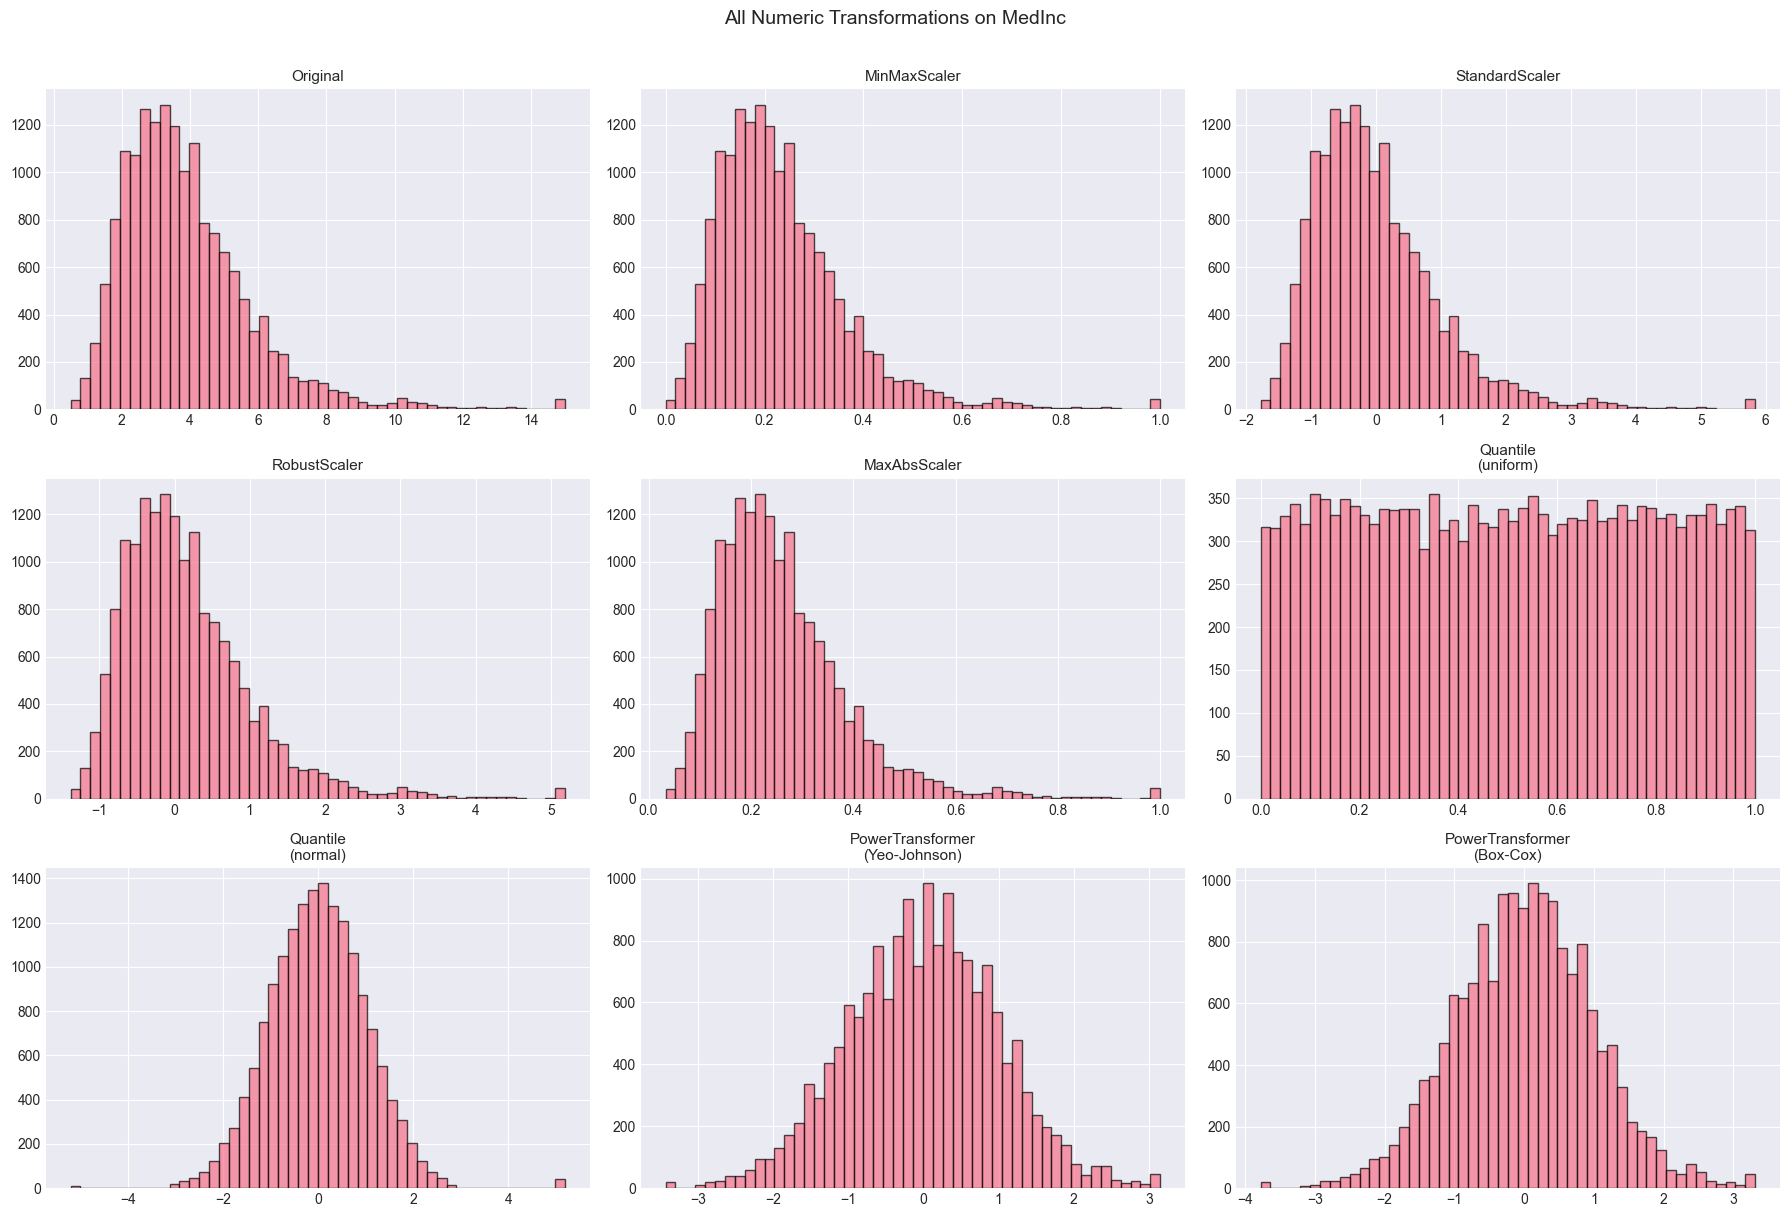

In [24]:
from sklearn.preprocessing import MaxAbsScaler

original = X_train.iloc[:, 0].values.reshape(-1, 1)
transformers = {
    'Original': None,
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler(),
    'MaxAbsScaler': MaxAbsScaler(),
    'Quantile\n(uniform)': QuantileTransformer(output_distribution='uniform', random_state=42),
    'Quantile\n(normal)': QuantileTransformer(output_distribution='normal', random_state=42),
    'PowerTransformer\n(Yeo-Johnson)': PowerTransformer(method='yeo-johnson'),
    'PowerTransformer\n(Box-Cox)': PowerTransformer(method='box-cox'),
}

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for ax, (name, t) in zip(axes.flat, transformers.items()):
    data = original if t is None else t.fit_transform(original)
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(name, fontsize=11)
plt.suptitle('All Numeric Transformations on MedInc', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2.2 Categorical Variable Transformations

### One-Hot Encoding
Transforms each categorical feature with $n$ categories into $n$ binary features.
- Drop one category to avoid perfect collinearity (for OLS without regularization)
- Can group infrequent categories

In [25]:
from sklearn.preprocessing import OneHotEncoder

cat_data = pd.DataFrame({
    'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue', 'Yellow', 'Red', 'Green', 'Red', 'Red'],
    'Size': ['S', 'M', 'L', 'M', 'XL', 'S', 'M', 'L', 'M', 'S']
})

# All categories
ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(cat_data)
print("All categories:")
print(pd.DataFrame(encoded, columns=ohe.get_feature_names_out()))

# Drop first (avoid collinearity)
ohe_drop = OneHotEncoder(sparse_output=False, drop='first')
encoded_drop = ohe_drop.fit_transform(cat_data)
print("\nDrop first:")
print(pd.DataFrame(encoded_drop, columns=ohe_drop.get_feature_names_out()))

# Group infrequent
ohe_infreq = OneHotEncoder(sparse_output=False, min_frequency=2, handle_unknown='infrequent_if_exist')
encoded_infreq = ohe_infreq.fit_transform(cat_data)
print("\nInfrequent grouped (min_frequency=2):")
print(pd.DataFrame(encoded_infreq, columns=ohe_infreq.get_feature_names_out()))
print(f"Infrequent: {ohe_infreq.infrequent_categories_}")

All categories:
   Color_Blue  Color_Green  Color_Red  Color_Yellow  Size_L  Size_M  Size_S  \
0         0.0          0.0        1.0           0.0     0.0     0.0     1.0   
1         1.0          0.0        0.0           0.0     0.0     1.0     0.0   
2         0.0          1.0        0.0           0.0     1.0     0.0     0.0   
3         0.0          0.0        1.0           0.0     0.0     1.0     0.0   
4         1.0          0.0        0.0           0.0     0.0     0.0     0.0   
5         0.0          0.0        0.0           1.0     0.0     0.0     1.0   
6         0.0          0.0        1.0           0.0     0.0     1.0     0.0   
7         0.0          1.0        0.0           0.0     1.0     0.0     0.0   
8         0.0          0.0        1.0           0.0     0.0     1.0     0.0   
9         0.0          0.0        1.0           0.0     0.0     0.0     1.0   

   Size_XL  
0      0.0  
1      0.0  
2      0.0  
3      0.0  
4      1.0  
5      0.0  
6      0.0  
7      0.0

### Ordinal Encoder
Transforms categories to integers. **Caution**: imposes an order.

In [26]:
from sklearn.preprocessing import OrdinalEncoder

# With explicit ordering
oe = OrdinalEncoder(categories=[['S', 'M', 'L', 'XL']])
encoded = oe.fit_transform(cat_data[['Size']])
print("Ordinal (S=0 < M=1 < L=2 < XL=3):")
print(pd.DataFrame(encoded, columns=['Size_ordinal']))

# Auto ordering
oe_auto = OrdinalEncoder()
encoded_auto = oe_auto.fit_transform(cat_data)
print("\nAuto ordering:")
print(pd.DataFrame(encoded_auto, columns=['Color_ord', 'Size_ord']))
print(f"Categories: {oe_auto.categories_}")

Ordinal (S=0 < M=1 < L=2 < XL=3):
   Size_ordinal
0           0.0
1           1.0
2           2.0
3           1.0
4           3.0
5           0.0
6           1.0
7           2.0
8           1.0
9           0.0

Auto ordering:
   Color_ord  Size_ord
0        2.0       2.0
1        0.0       1.0
2        1.0       0.0
3        2.0       1.0
4        0.0       3.0
5        3.0       2.0
6        2.0       1.0
7        1.0       0.0
8        2.0       1.0
9        2.0       2.0
Categories: [array(['Blue', 'Green', 'Red', 'Yellow'], dtype=object), array(['L', 'M', 'S', 'XL'], dtype=object)]


### Target Encoder
Encodes each category as the mean of the target for that category.
Uses internal cross-fitting to prevent target leakage.

In [27]:
from sklearn.preprocessing import TargetEncoder

cat_train = pd.DataFrame({
    'City': ['NYC', 'LA', 'NYC', 'Chicago', 'LA', 'NYC', 'Chicago', 'LA', 'NYC', 'Chicago'] * 10,
    'Type': ['A', 'B', 'A', 'B', 'A', 'B', 'A', 'B', 'A', 'A'] * 10
})
y_cat = np.array([100, 50, 110, 30, 55, 105, 35, 45, 95, 40] * 10) + np.random.normal(0, 5, 100)

te = TargetEncoder(smooth='auto', target_type='continuous')
encoded = te.fit_transform(cat_train, y_cat)
result = pd.DataFrame(encoded, columns=['City_te', 'Type_te'])
result['City'] = cat_train['City'].values
result['y'] = y_cat
print("Target Encoded means:")
print(result.groupby('City')[['City_te', 'y']].mean().round(2))

Target Encoded means:
         City_te       y
City                    
Chicago    35.63   35.66
LA         50.70   50.48
NYC       101.98  102.13


### Label Encoder (for target variable only)

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
labels = ['cat', 'dog', 'bird', 'cat', 'bird', 'dog', 'cat']
encoded = le.fit_transform(labels)
print(f"Original: {labels}")
print(f"Encoded:  {encoded}")
print(f"Classes:  {le.classes_}")
print(f"Inverse:  {list(le.inverse_transform(encoded))}")

Original: ['cat', 'dog', 'bird', 'cat', 'bird', 'dog', 'cat']
Encoded:  [1 2 0 1 0 2 1]
Classes:  ['bird' 'cat' 'dog']
Inverse:  [np.str_('cat'), np.str_('dog'), np.str_('bird'), np.str_('cat'), np.str_('bird'), np.str_('dog'), np.str_('cat')]


### ColumnTransformer for Mixed Data Types

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

df_mixed = pd.DataFrame({
    'Income': np.random.exponential(50000, 500),
    'Age': np.random.normal(40, 12, 500).clip(18, 80),
    'Education': np.random.choice(['HS', 'BS', 'MS', 'PhD'], 500, p=[0.3, 0.4, 0.2, 0.1]),
    'City': np.random.choice(['NYC', 'LA', 'Chicago', 'Houston'], 500),
})
y_mixed = df_mixed['Income'] * 0.5 + df_mixed['Age'] * 100 + np.random.normal(0, 5000, 500)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['Income', 'Age']),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), ['Education', 'City']),
])

pipe = Pipeline([('preprocess', preprocessor), ('model', LinearRegression())])
scores = cross_val_score(pipe, df_mixed, y_mixed, cv=5, scoring='r2')
print(f"Pipeline CV R2: {scores.mean():.4f} (+/- {scores.std():.4f})")
print(f"Feature names: {preprocessor.fit(df_mixed).get_feature_names_out()}")

Pipeline CV R2: 0.9562 (+/- 0.0098)
Feature names: ['num__Income' 'num__Age' 'cat__Education_HS' 'cat__Education_MS'
 'cat__Education_PhD' 'cat__City_Houston' 'cat__City_LA' 'cat__City_NYC']


## 2.3 Feature Interactions

We can look for interactions between variables (numeric & numeric, categorical & categorical, numeric & categorical) via multiplication, division, subtraction, etc.

In [30]:
poly_interact = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_interact = poly_interact.fit_transform(X_train[['MedInc', 'HouseAge', 'AveRooms']])
print(f"3 features -> {X_interact.shape[1]} interaction features")
print(f"Names: {poly_interact.get_feature_names_out()}")

# Manual feature engineering
df_eng = X_train.copy()
df_eng['Rooms_per_Person'] = df_eng['AveRooms'] / df_eng['AveOccup']
df_eng['Income_x_Rooms'] = df_eng['MedInc'] * df_eng['AveRooms']
df_eng['Age_squared'] = df_eng['HouseAge'] ** 2
df_eng['Log_Population'] = np.log1p(df_eng['Population'])
print(f"\nOriginal: {X_train.shape[1]} features -> Engineered: {df_eng.shape[1]} features")
print(f"New columns: {[c for c in df_eng.columns if c not in X_train.columns]}")

3 features -> 6 interaction features
Names: ['MedInc' 'HouseAge' 'AveRooms' 'MedInc HouseAge' 'MedInc AveRooms'
 'HouseAge AveRooms']

Original: 8 features -> Engineered: 12 features
New columns: ['Rooms_per_Person', 'Income_x_Rooms', 'Age_squared', 'Log_Population']


# 3. Regularization

Regularization modifies the loss function to incorporate information about parameter values — a tool to fight **overfitting** (excessive model variance):

$$\min_f \sum_{i=1}^{n} V(f(x_i), y_i) + \lambda R(f)$$

| Type | Name | Properties |
|------|------|-----------|
| **L1** | Lasso | Shrinks coefficients to exactly 0 — good for **feature selection** |
| **L2** | Ridge | Makes coefficients smaller — good for **multicollinearity** |
| **L1+L2** | Elastic Net | Combination — usually the most reasonable approach |

## 3.1 Comparing Regularization Strategies

In [31]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    'OLS (no regularization)': LinearRegression(),
    'Ridge (L2, alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (L2, alpha=10.0)': Ridge(alpha=10.0),
    'Lasso (L1, alpha=0.01)': Lasso(alpha=0.01),
    'Lasso (L1, alpha=0.1)': Lasso(alpha=0.1),
    'ElasticNet (a=0.01, l1=0.5)': ElasticNet(alpha=0.01, l1_ratio=0.5),
    'ElasticNet (a=0.1, l1=0.7)': ElasticNet(alpha=0.1, l1_ratio=0.7),
}

print(f"{'Model':<35} {'CV R2':>8} {'Std':>8}")
print("-" * 55)
for name, model in models.items():
    scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring='r2')
    print(f"{name:<35} {scores.mean():>8.4f} {scores.std():>8.4f}")

Model                                  CV R2      Std
-------------------------------------------------------
OLS (no regularization)               0.6115   0.0065
Ridge (L2, alpha=1.0)                 0.6115   0.0065
Ridge (L2, alpha=10.0)                0.6115   0.0064
Lasso (L1, alpha=0.01)                0.6077   0.0047
Lasso (L1, alpha=0.1)                 0.4971   0.0041
ElasticNet (a=0.01, l1=0.5)           0.6093   0.0052
ElasticNet (a=0.1, l1=0.7)            0.5056   0.0039


## 3.2 Lasso Feature Selection Effect

alpha=0.001  -> 0 zero coefficients: [ 0.8491  0.1233 -0.2813  0.326  -0.0011 -0.0399 -0.8858 -0.8581]
alpha=0.01   -> 1 zero coefficients: [ 0.801   0.1271 -0.1628  0.2062 -0.     -0.0306 -0.7901 -0.7557]
alpha=0.05   -> 4 zero coefficients: [ 0.742   0.1396 -0.      0.      0.     -0.     -0.2592 -0.2164]
alpha=0.1    -> 5 zero coefficients: [ 0.7106  0.1065 -0.      0.     -0.     -0.     -0.0115 -0.    ]
alpha=0.5    -> 7 zero coefficients: [ 0.2985  0.      0.      0.      0.      0.     -0.      0.    ]
alpha=1.0    -> 8 zero coefficients: [0. 0. 0. 0. 0. 0. 0. 0.]


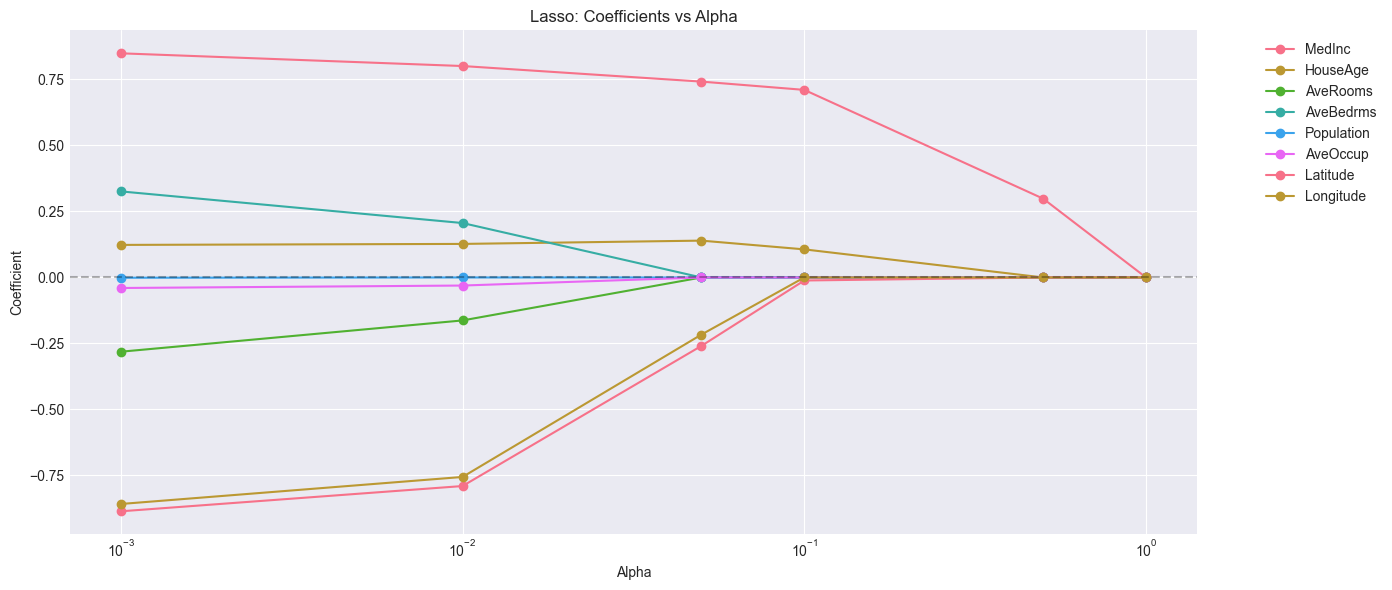

In [32]:
alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

fig, ax = plt.subplots(figsize=(14, 6))
coef_matrix = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha).fit(X_train_s, y_train)
    coef_matrix.append(lasso.coef_)
    n_zero = (lasso.coef_ == 0).sum()
    print(f"alpha={alpha:<6} -> {n_zero} zero coefficients: {lasso.coef_.round(4)}")

coef_matrix = np.array(coef_matrix)
for i in range(coef_matrix.shape[1]):
    ax.plot(alphas, coef_matrix[:, i], 'o-', label=feature_names[i])

ax.set_xscale('log')
ax.set_xlabel('Alpha')
ax.set_ylabel('Coefficient')
ax.set_title('Lasso: Coefficients vs Alpha')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 3.3 Regularization Paths: Lasso vs Ridge vs Elastic Net

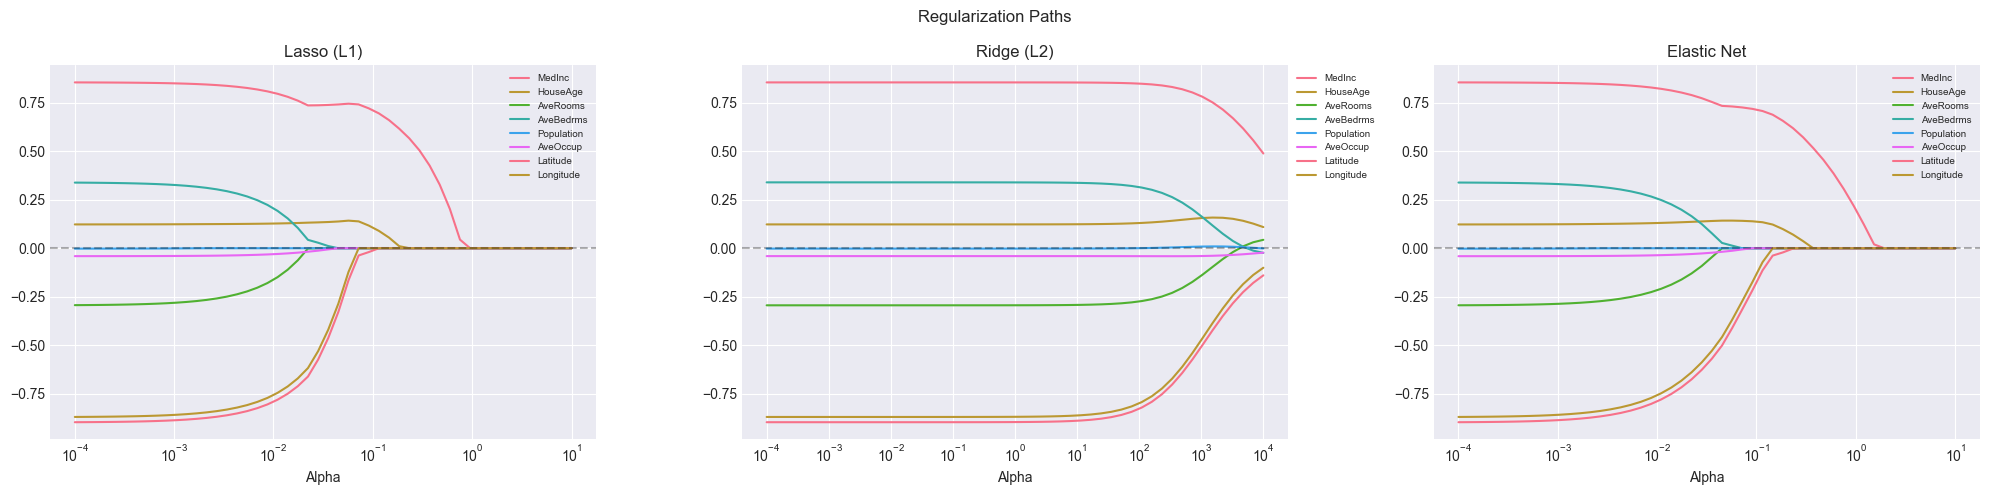

In [33]:
from sklearn.linear_model import lasso_path, enet_path

alphas_grid = np.logspace(-4, 1, 50)

alphas_lasso, coefs_lasso, _ = lasso_path(X_train_s, y_train, alphas=alphas_grid)
alphas_enet, coefs_enet, _ = enet_path(X_train_s, y_train, l1_ratio=0.5, alphas=alphas_grid)

ridge_coefs = []
ridge_alphas = np.logspace(-4, 4, 50)
for a in ridge_alphas:
    ridge_coefs.append(Ridge(alpha=a).fit(X_train_s, y_train).coef_)
ridge_coefs = np.array(ridge_coefs)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i in range(coefs_lasso.shape[0]):
    axes[0].plot(alphas_lasso, coefs_lasso[i], label=feature_names[i])
axes[0].set_xscale('log'); axes[0].set_title('Lasso (L1)'); axes[0].set_xlabel('Alpha')

for i in range(ridge_coefs.shape[1]):
    axes[1].plot(ridge_alphas, ridge_coefs[:, i], label=feature_names[i])
axes[1].set_xscale('log'); axes[1].set_title('Ridge (L2)'); axes[1].set_xlabel('Alpha')

for i in range(coefs_enet.shape[0]):
    axes[2].plot(alphas_enet, coefs_enet[i], label=feature_names[i])
axes[2].set_xscale('log'); axes[2].set_title('Elastic Net'); axes[2].set_xlabel('Alpha')

for ax in axes:
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax.legend(fontsize=7, bbox_to_anchor=(1.0, 1))
plt.suptitle('Regularization Paths')
plt.tight_layout()
plt.show()

## 3.4 Automatic Alpha Selection with CV

In [34]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

ridge_cv = RidgeCV(alphas=np.logspace(-4, 4, 50), cv=5, scoring='r2')
ridge_cv.fit(X_train_s, y_train)
print(f"RidgeCV     -> best alpha: {ridge_cv.alpha_:.6f}, test R2: {ridge_cv.score(X_test_s, y_test):.4f}")

lasso_cv = LassoCV(alphas=np.logspace(-4, 1, 50), cv=5, random_state=42)
lasso_cv.fit(X_train_s, y_train)
print(f"LassoCV     -> best alpha: {lasso_cv.alpha_:.6f}, test R2: {lasso_cv.score(X_test_s, y_test):.4f}")

enet_cv = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], alphas=np.logspace(-4, 1, 50), cv=5, random_state=42)
enet_cv.fit(X_train_s, y_train)
print(f"ElasticNetCV -> best alpha: {enet_cv.alpha_:.6f}, l1_ratio: {enet_cv.l1_ratio_:.2f}, test R2: {enet_cv.score(X_test_s, y_test):.4f}")

RidgeCV     -> best alpha: 0.000100, test R2: 0.5758
LassoCV     -> best alpha: 0.000655, test R2: 0.5765
ElasticNetCV -> best alpha: 0.000655, l1_ratio: 0.90, test R2: 0.5765


## 3.5 Regularization for Classification

In [35]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=42, stratify=cancer.target)
sc = StandardScaler()
Xc_tr_s = sc.fit_transform(Xc_tr)
Xc_te_s = sc.transform(Xc_te)

classifiers = {
    'LogReg (no penalty)': LogisticRegression(penalty=None, max_iter=5000),
    'LogReg (L2, C=1)': LogisticRegression(penalty='l2', C=1.0, max_iter=5000),
    'LogReg (L2, C=0.01)': LogisticRegression(penalty='l2', C=0.01, max_iter=5000),
    'LogReg (L1, C=1)': LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=5000),
    'LogReg (ElasticNet)': LogisticRegression(penalty='elasticnet', C=1.0, l1_ratio=0.5, solver='saga', max_iter=5000),
    'SGD (L1)': SGDClassifier(loss='log_loss', penalty='l1', alpha=0.01, random_state=42),
    'SGD (L2)': SGDClassifier(loss='log_loss', penalty='l2', alpha=0.01, random_state=42),
    'SGD (ElasticNet)': SGDClassifier(loss='log_loss', penalty='elasticnet', alpha=0.01, l1_ratio=0.5, random_state=42),
}

print(f"{'Model':<25} {'Accuracy':>10} {'Non-zero':>10}")
print("-" * 48)
for name, clf in classifiers.items():
    clf.fit(Xc_tr_s, yc_tr)
    print(f"{name:<25} {clf.score(Xc_te_s, yc_te):>10.4f} {np.sum(clf.coef_ != 0):>10}")

Model                       Accuracy   Non-zero
------------------------------------------------
LogReg (no penalty)           0.9211         30
LogReg (L2, C=1)              0.9825         30
LogReg (L2, C=0.01)           0.9474         30
LogReg (L1, C=1)              0.9912         18
LogReg (ElasticNet)           0.9825         27
SGD (L1)                      0.9737         16
SGD (L2)                      0.9825         30
SGD (ElasticNet)              0.9825         19


# 4. Feature Selection

After feature engineering, we should have many variables. Not all models can select variables themselves (e.g. OLS, KNN, SVM). Recommended **two-step approach**:

1. **Univariate/bivariate**: Variance Threshold, Mutual Information, F-test, Chi2, Correlation
2. **Multivariate**: Embedded (Lasso, Boruta, SHAP), Wrapper (Backward, Forward, RFE)

## 4.1 Univariate Feature Selection

In [36]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, SelectPercentile,
    f_classif, chi2, mutual_info_classif
)

cancer = load_breast_cancer()
X_sel = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_sel = cancer.target

print(f"Original features: {X_sel.shape[1]}")

Original features: 30


### Variance Threshold
Removes features with variance below a threshold.

In [37]:
vt = VarianceThreshold(threshold=0.5)
X_vt = vt.fit_transform(X_sel)
removed = X_sel.columns[~vt.get_support()]
print(f"Variance Threshold (>0.5): {X_sel.shape[1]} -> {X_vt.shape[1]} features")
print(f"Removed: {list(removed)}")

# Show variances of all features
variances = pd.Series(X_sel.var(), name='Variance').sort_values()
print(f"\nFeatures with lowest variance:")
print(variances.head(10).round(4))

Variance Threshold (>0.5): 30 -> 10 features
Removed: ['mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Features with lowest variance:
fractal dimension error    0.0000
smoothness error           0.0000
concave points error       0.0000
mean fractal dimension     0.0000
symmetry error             0.0001
mean smoothness            0.0002
compactness error          0.0003
worst fractal dimension    0.0003
worst smoothness           0.0005
mean symmetry              0.0008
Name: Variance, dtype: float64


### F-test (ANOVA) and Chi-squared Test

In [38]:
# F-test for classification
selector_f = SelectKBest(score_func=f_classif, k=10)
X_f = selector_f.fit_transform(X_sel, y_sel)
f_scores = pd.DataFrame({
    'Feature': cancer.feature_names,
    'F-score': selector_f.scores_,
    'p-value': selector_f.pvalues_,
    'Selected': selector_f.get_support()
}).sort_values('F-score', ascending=False)
print("Top 10 by F-test:")
print(f_scores.head(10).to_string(index=False))

# Chi2 (requires non-negative features)
from sklearn.preprocessing import MinMaxScaler
X_pos = MinMaxScaler().fit_transform(X_sel)
selector_chi2 = SelectKBest(score_func=chi2, k=10)
selector_chi2.fit_transform(X_pos, y_sel)
chi2_scores = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Chi2-score': selector_chi2.scores_,
    'Selected': selector_chi2.get_support()
}).sort_values('Chi2-score', ascending=False)
print("\nTop 10 by Chi2:")
print(chi2_scores.head(10).to_string(index=False))

Top 10 by F-test:
             Feature    F-score       p-value  Selected
worst concave points 964.385393 1.969100e-124      True
     worst perimeter 897.944219 5.771397e-119      True
 mean concave points 861.676020 7.101150e-116      True
        worst radius 860.781707 8.482292e-116      True
      mean perimeter 697.235272 8.436251e-101      True
          worst area 661.600206  2.828848e-97      True
         mean radius 646.981021  8.465941e-96      True
           mean area 573.060747  4.734564e-88      True
      mean concavity 533.793126  9.966556e-84      True
     worst concavity 436.691939  2.464664e-72      True

Top 10 by Chi2:
             Feature  Chi2-score  Selected
 mean concave points   52.405743      True
worst concave points   46.341648      True
      mean concavity   46.186395      True
          worst area   35.043882      True
     worst perimeter   34.438091      True
        worst radius   34.124937      True
     worst concavity   31.563031      True
     

### Mutual Information
Measures mutual dependence between variables (related to entropy).

In [39]:
selector_mi = SelectKBest(score_func=mutual_info_classif, k=10)
selector_mi.fit(X_sel, y_sel)
mi_scores = pd.DataFrame({
    'Feature': cancer.feature_names,
    'MI-score': selector_mi.scores_,
    'Selected': selector_mi.get_support()
}).sort_values('MI-score', ascending=False)
print("Top 10 by Mutual Information:")
print(mi_scores.head(10).to_string(index=False))

Top 10 by Mutual Information:
             Feature  MI-score  Selected
     worst perimeter  0.475309      True
          worst area  0.464730      True
        worst radius  0.452300      True
 mean concave points  0.438757      True
worst concave points  0.436500      True
      mean perimeter  0.404718      True
      mean concavity  0.375502      True
         mean radius  0.366942      True
           mean area  0.359263      True
          area error  0.341416      True


### SelectPercentile
Select features based on percentile of the highest scores.

In [40]:
selector_pct = SelectPercentile(score_func=f_classif, percentile=30)
X_pct = selector_pct.fit_transform(X_sel, y_sel)
print(f"SelectPercentile (top 30%): {X_sel.shape[1]} -> {X_pct.shape[1]} features")
print(f"Selected: {list(X_sel.columns[selector_pct.get_support()])}")

SelectPercentile (top 30%): 30 -> 9 features
Selected: ['mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'worst radius', 'worst perimeter', 'worst area', 'worst concave points']


### Correlation Analysis

Top 10 features by absolute correlation with target:
                      pearson  spearman  kendall
worst perimeter        0.7829    0.7963   0.6509
worst radius           0.7765    0.7879   0.6442
worst area             0.7338    0.7869   0.6431
worst concave points   0.7936    0.7817   0.6391
mean concave points    0.7766    0.7779   0.6359
mean perimeter         0.7426    0.7485   0.6118
mean area              0.7090    0.7341   0.6000
mean concavity         0.6964    0.7333   0.5994
mean radius            0.7300    0.7328   0.5991
area error             0.5482    0.7142   0.5837


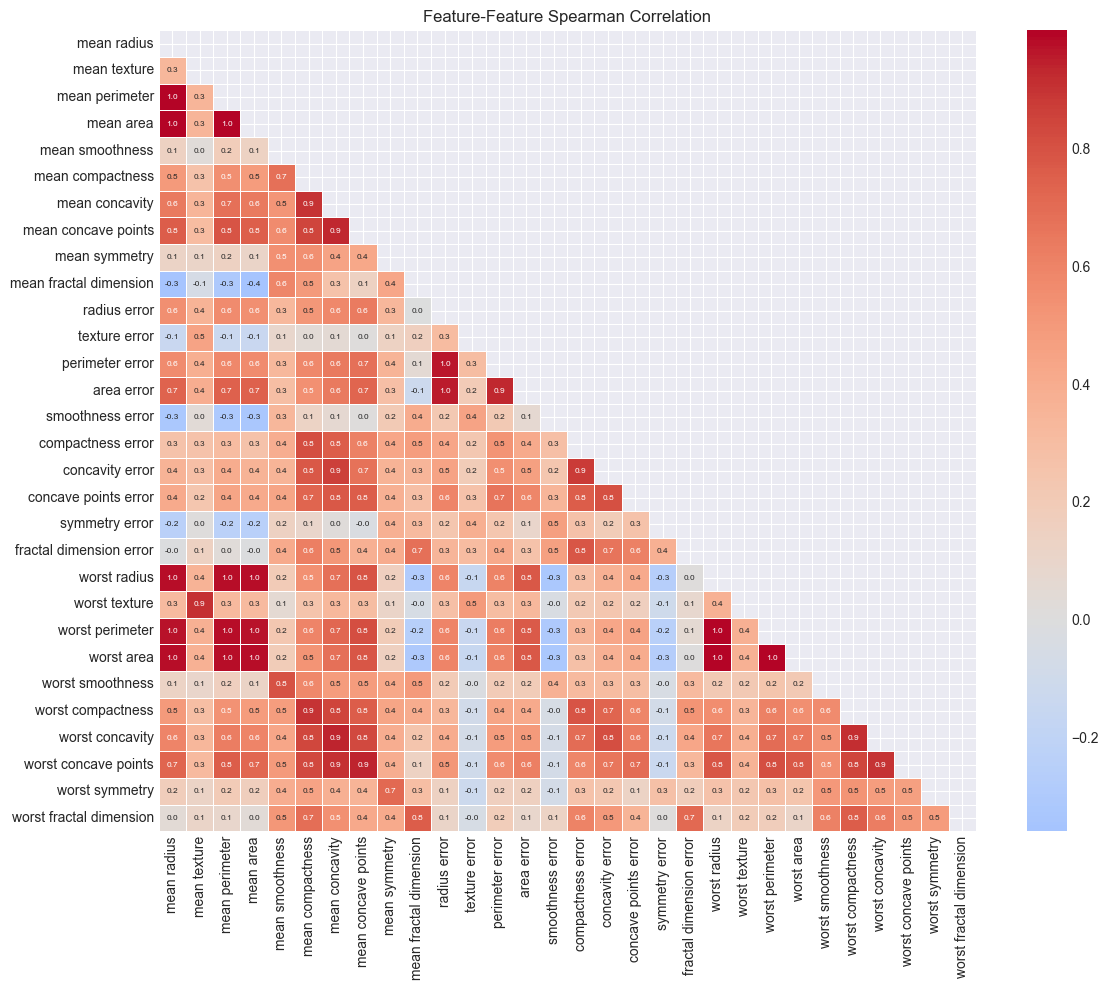

In [41]:
# Pearson, Spearman, Kendall correlations with target
corr_methods = {}
for method in ['pearson', 'spearman', 'kendall']:
    corr = X_sel.apply(lambda col: col.corr(pd.Series(y_sel), method=method))
    corr_methods[method] = corr.abs()

corr_df = pd.DataFrame(corr_methods).sort_values('spearman', ascending=False)
print("Top 10 features by absolute correlation with target:")
print(corr_df.head(10).round(4))

# Feature-feature correlation heatmap (to detect multicollinearity)
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = X_sel.corr(method='spearman')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, ax=ax, fmt='.1f',
            annot=True, annot_kws={'size': 6}, linewidths=0.5)
ax.set_title('Feature-Feature Spearman Correlation')
plt.tight_layout()
plt.show()

## 4.2 Multivariate Feature Selection

### Recursive Feature Elimination (RFE)

In [42]:
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LogisticRegression

# RFE with Logistic Regression
lr = LogisticRegression(max_iter=5000, C=1.0, random_state=42)
scaler_sel = StandardScaler()
X_sel_s = scaler_sel.fit_transform(X_sel)

rfe = RFE(estimator=lr, n_features_to_select=10, step=1)
rfe.fit(X_sel_s, y_sel)
print("RFE selected features (top 10):")
selected = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')
print(selected.head(15).to_string(index=False))

RFE selected features (top 10):
             Feature  Selected  Ranking
        radius error      True        1
       worst texture      True        1
     worst perimeter      True        1
   compactness error      True        1
          area error      True        1
          worst area      True        1
     worst concavity      True        1
        worst radius      True        1
worst concave points      True        1
 mean concave points      True        1
    worst smoothness     False        2
           mean area     False        3
     perimeter error     False        4
    mean compactness     False        5
      worst symmetry     False        6


### RFECV (RFE with Cross-Validation)

Optimal number of features: 30
Selected features: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]


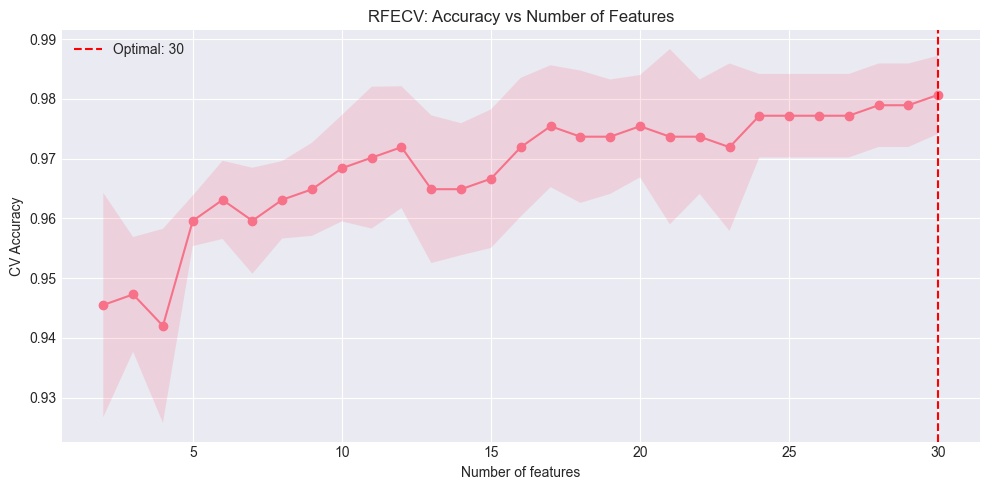

In [43]:
rfecv = RFECV(estimator=lr, step=1, cv=5, scoring='accuracy', min_features_to_select=2)
rfecv.fit(X_sel_s, y_sel)
print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Selected features: {list(cancer.feature_names[rfecv.support_])}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(2, len(rfecv.cv_results_['mean_test_score']) + 2), rfecv.cv_results_['mean_test_score'], 'o-')
ax.fill_between(range(2, len(rfecv.cv_results_['mean_test_score']) + 2),
                rfecv.cv_results_['mean_test_score'] - rfecv.cv_results_['std_test_score'],
                rfecv.cv_results_['mean_test_score'] + rfecv.cv_results_['std_test_score'], alpha=0.2)
ax.set_xlabel('Number of features')
ax.set_ylabel('CV Accuracy')
ax.set_title('RFECV: Accuracy vs Number of Features')
ax.axvline(x=rfecv.n_features_, color='red', linestyle='--', label=f'Optimal: {rfecv.n_features_}')
ax.legend()
plt.tight_layout()
plt.show()

### Sequential Feature Selection (Forward & Backward)

In [44]:
from sklearn.feature_selection import SequentialFeatureSelector

# Forward selection
sfs_forward = SequentialFeatureSelector(lr, n_features_to_select=10, direction='forward', cv=5, scoring='accuracy')
sfs_forward.fit(X_sel_s, y_sel)
print(f"Forward selection (10 features): {list(cancer.feature_names[sfs_forward.get_support()])}")

# Backward selection
sfs_backward = SequentialFeatureSelector(lr, n_features_to_select=10, direction='backward', cv=5, scoring='accuracy')
sfs_backward.fit(X_sel_s, y_sel)
print(f"Backward selection (10 features): {list(cancer.feature_names[sfs_backward.get_support()])}")

Forward selection (10 features): [np.str_('mean radius'), np.str_('mean concavity'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('concavity error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst smoothness'), np.str_('worst symmetry')]
Backward selection (10 features): [np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('area error'), np.str_('concave points error'), np.str_('fractal dimension error'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst smoothness'), np.str_('worst concave points'), np.str_('worst symmetry')]


### Feature Importance from Tree-Based Models

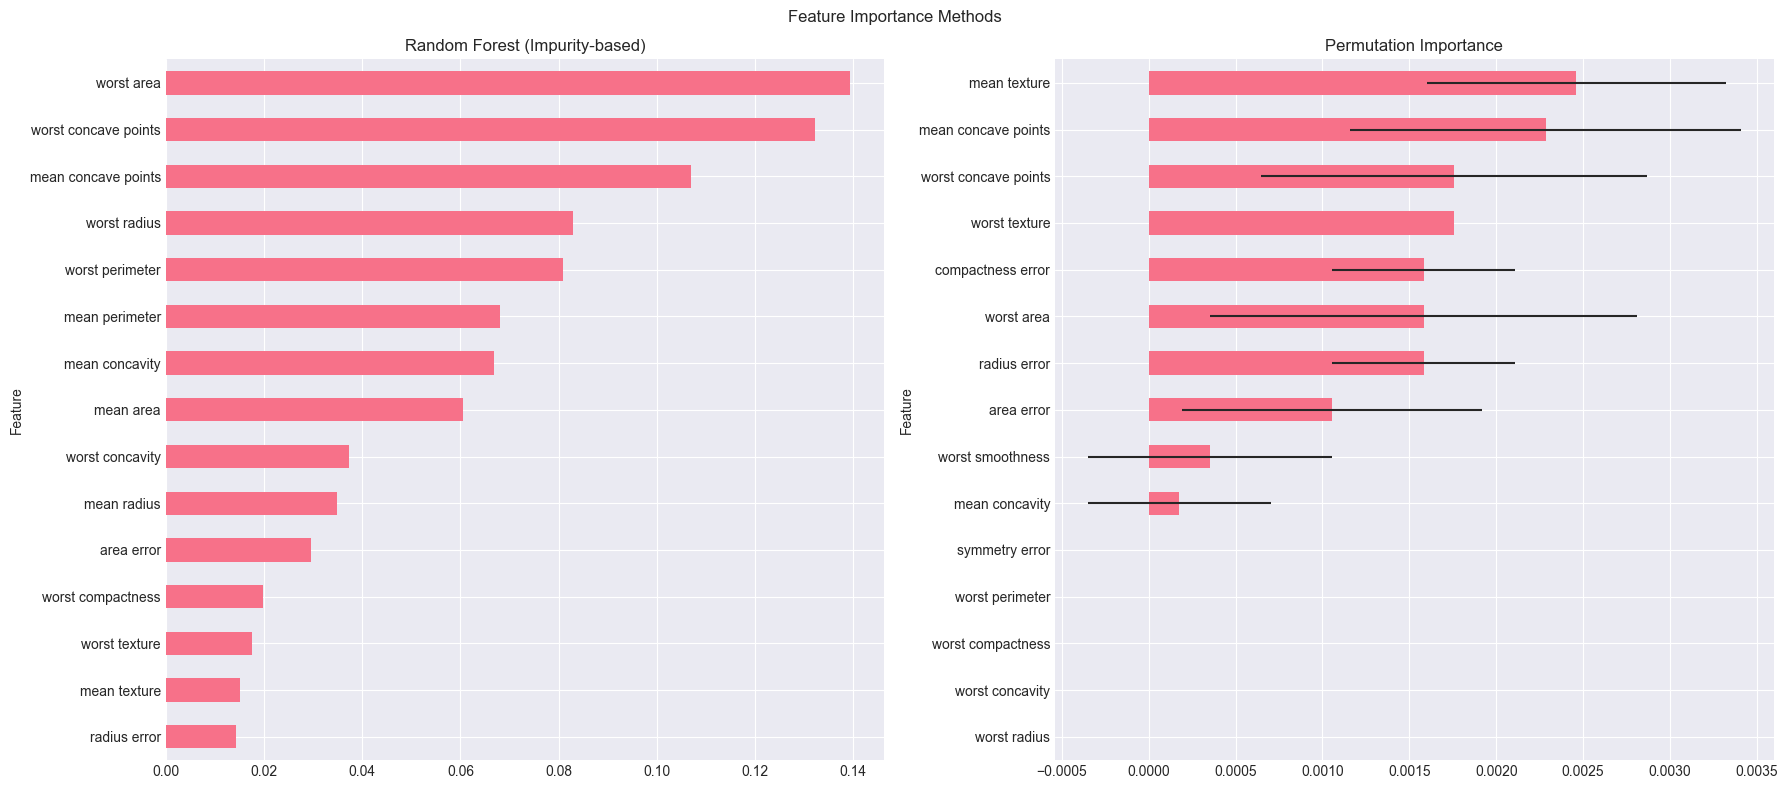

In [45]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

# Random Forest feature importance (impurity-based)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_sel_s, y_sel)

fi_rf = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

# Permutation importance (model-agnostic)
perm_imp = permutation_importance(rf, X_sel_s, y_sel, n_repeats=10, random_state=42, scoring='accuracy')
fi_perm = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

fi_rf.head(15).plot.barh(x='Feature', y='Importance', ax=axes[0], legend=False)
axes[0].set_title('Random Forest (Impurity-based)')
axes[0].invert_yaxis()

fi_perm.head(15).plot.barh(x='Feature', y='Importance', xerr='Std', ax=axes[1], legend=False)
axes[1].set_title('Permutation Importance')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance Methods')
plt.tight_layout()
plt.show()

### Embedded: SelectFromModel (Lasso-based)

In [46]:
from sklearn.feature_selection import SelectFromModel

lasso = Lasso(alpha=0.01).fit(X_sel_s, y_sel)
sfm = SelectFromModel(lasso, prefit=True)
X_sfm = sfm.transform(X_sel_s)
print(f"SelectFromModel (Lasso, alpha=0.01): {X_sel.shape[1]} -> {X_sfm.shape[1]} features")
print(f"Selected: {list(cancer.feature_names[sfm.get_support()])}")

# With Random Forest
sfm_rf = SelectFromModel(rf, prefit=True, threshold='mean')
X_sfm_rf = sfm_rf.transform(X_sel_s)
print(f"\nSelectFromModel (RF, threshold=mean): {X_sel.shape[1]} -> {X_sfm_rf.shape[1]} features")
print(f"Selected: {list(cancer.feature_names[sfm_rf.get_support()])}")

SelectFromModel (Lasso, alpha=0.01): 30 -> 12 features
Selected: [np.str_('mean texture'), np.str_('mean concave points'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('smoothness error'), np.str_('concavity error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst smoothness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry')]

SelectFromModel (RF, threshold=mean): 30 -> 10 features
Selected: [np.str_('mean radius'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('worst radius'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst concavity'), np.str_('worst concave points')]


# 5. Classes Rebalancing

Imbalanced classes negatively impact the cost function (the algorithm focuses on the majority class) and mislead evaluation metrics like Accuracy.

Techniques:
1. **Modification of the cost function** (class weights)
2. **Undersampling** (reduce majority class)
3. **Oversampling** (increase minority class)
4. **Combination** (over + under)

**Warning**: rebalancing must be done **separately for each fold** in cross-validation to avoid leakage!

## 5.1 Creating an Imbalanced Dataset

In [47]:
from sklearn.datasets import make_classification

X_imb, y_imb = make_classification(
    n_samples=2000, n_features=20, n_informative=10, n_redundant=5,
    n_classes=2, weights=[0.95, 0.05], random_state=42, flip_y=0.01
)

print(f"Class distribution: {dict(zip(*np.unique(y_imb, return_counts=True)))}")
print(f"Imbalance ratio: {np.sum(y_imb==0)/np.sum(y_imb==1):.1f}:1")

Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb)

Class distribution: {np.int64(0): np.int64(1891), np.int64(1): np.int64(109)}
Imbalance ratio: 17.3:1


## 5.2 Cost Function Modification (Class Weights)

$$L(X; \theta) = \sum_i W_{y_i} L(x_i; \theta) \quad \text{where} \quad W_c = \frac{N}{\text{number of samples of class } c}$$

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

# Without class weights
lr_no_w = LogisticRegression(max_iter=1000, random_state=42)
lr_no_w.fit(Xi_tr, yi_tr)
print("=== Without class weights ===")
print(classification_report(yi_te, lr_no_w.predict(Xi_te)))

# With class weights
lr_w = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_w.fit(Xi_tr, yi_tr)
print("=== With class_weight='balanced' ===")
print(classification_report(yi_te, lr_w.predict(Xi_te)))

=== Without class weights ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       378
           1       0.44      0.18      0.26        22

    accuracy                           0.94       400
   macro avg       0.70      0.58      0.61       400
weighted avg       0.93      0.94      0.93       400

=== With class_weight='balanced' ===
              precision    recall  f1-score   support

           0       0.99      0.83      0.90       378
           1       0.22      0.82      0.35        22

    accuracy                           0.83       400
   macro avg       0.60      0.83      0.63       400
weighted avg       0.95      0.83      0.87       400



## 5.3 Undersampling

Reducing the number of observations from the majority class.

### Prototype generation: Cluster Centroids
Uses K-means to synthesize new majority class samples at cluster centers.

### Prototype selection: Random Undersampler, Tomek Links, Edited Nearest Neighbours

In [49]:
from imblearn.under_sampling import (
    RandomUnderSampler, ClusterCentroids, TomekLinks,
    EditedNearestNeighbours, RepeatedEditedNearestNeighbours,
    NearMiss
)

undersamplers = {
    'RandomUnderSampler': RandomUnderSampler(random_state=42),
    'RandomUnderSampler (0.5)': RandomUnderSampler(sampling_strategy=0.5, random_state=42),
    'ClusterCentroids': ClusterCentroids(random_state=42),
    'TomekLinks': TomekLinks(),
    'EditedNearestNeighbours': EditedNearestNeighbours(),
    'RepeatedEditedNN': RepeatedEditedNearestNeighbours(),
    'NearMiss (v1)': NearMiss(version=1),
}

print(f"{'Method':<30} {'Majority':>10} {'Minority':>10} {'Ratio':>8}")
print("-" * 62)
print(f"{'Original':<30} {np.sum(yi_tr==0):>10} {np.sum(yi_tr==1):>10} {np.sum(yi_tr==0)/np.sum(yi_tr==1):>8.1f}")
for name, sampler in undersamplers.items():
    X_res, y_res = sampler.fit_resample(Xi_tr, yi_tr)
    print(f"{name:<30} {np.sum(y_res==0):>10} {np.sum(y_res==1):>10} {np.sum(y_res==0)/max(np.sum(y_res==1),1):>8.1f}")

Method                           Majority   Minority    Ratio
--------------------------------------------------------------
Original                             1513         87     17.4
RandomUnderSampler                     87         87      1.0
RandomUnderSampler (0.5)              174         87      2.0
ClusterCentroids                       87         87      1.0
TomekLinks                           1504         87     17.3
EditedNearestNeighbours              1455         87     16.7
RepeatedEditedNN                     1452         87     16.7
NearMiss (v1)                          87         87      1.0


## 5.4 Oversampling

Increasing the number of observations from the minority class.

### Random Oversampler, SMOTE, Borderline SMOTE, SVM SMOTE, KMeans SMOTE, ADASYN

In [50]:
from imblearn.over_sampling import (
    RandomOverSampler, SMOTE, BorderlineSMOTE,
    SVMSMOTE, KMeansSMOTE, ADASYN
)

oversamplers = {
    'RandomOverSampler': RandomOverSampler(random_state=42),
    'SMOTE': SMOTE(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
    'SVMSMOTE': SVMSMOTE(random_state=42),
    'KMeansSMOTE': KMeansSMOTE(random_state=42, cluster_balance_threshold=0.01),
    'ADASYN': ADASYN(random_state=42),
}

print(f"{'Method':<25} {'Majority':>10} {'Minority':>10} {'Ratio':>8}")
print("-" * 57)
print(f"{'Original':<25} {np.sum(yi_tr==0):>10} {np.sum(yi_tr==1):>10} {np.sum(yi_tr==0)/np.sum(yi_tr==1):>8.1f}")
for name, sampler in oversamplers.items():
    X_res, y_res = sampler.fit_resample(Xi_tr, yi_tr)
    print(f"{name:<25} {np.sum(y_res==0):>10} {np.sum(y_res==1):>10} {np.sum(y_res==0)/max(np.sum(y_res==1),1):>8.1f}")

Method                      Majority   Minority    Ratio
---------------------------------------------------------
Original                        1513         87     17.4
RandomOverSampler               1513       1513      1.0
SMOTE                           1513       1513      1.0
BorderlineSMOTE                 1513       1513      1.0
SVMSMOTE                        1513       1513      1.0
KMeansSMOTE                     1513       1517      1.0
ADASYN                          1513       1505      1.0


## 5.5 Combination: SMOTE + Cleaning

SMOTE can generate noisy samples. Cleaning with Tomek Links or ENN removes overlap.

In [51]:
from imblearn.combine import SMOTETomek, SMOTEENN

combiners = {
    'SMOTETomek': SMOTETomek(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42),
}

print(f"{'Method':<20} {'Majority':>10} {'Minority':>10}")
print("-" * 44)
print(f"{'Original':<20} {np.sum(yi_tr==0):>10} {np.sum(yi_tr==1):>10}")
for name, sampler in combiners.items():
    X_res, y_res = sampler.fit_resample(Xi_tr, yi_tr)
    print(f"{name:<20} {np.sum(y_res==0):>10} {np.sum(y_res==1):>10}")

Method                 Majority   Minority
--------------------------------------------
Original                   1513         87
SMOTETomek                 1512       1512
SMOTEENN                   1317       1507


## 5.6 Visualizing Resampling Effects (2D)

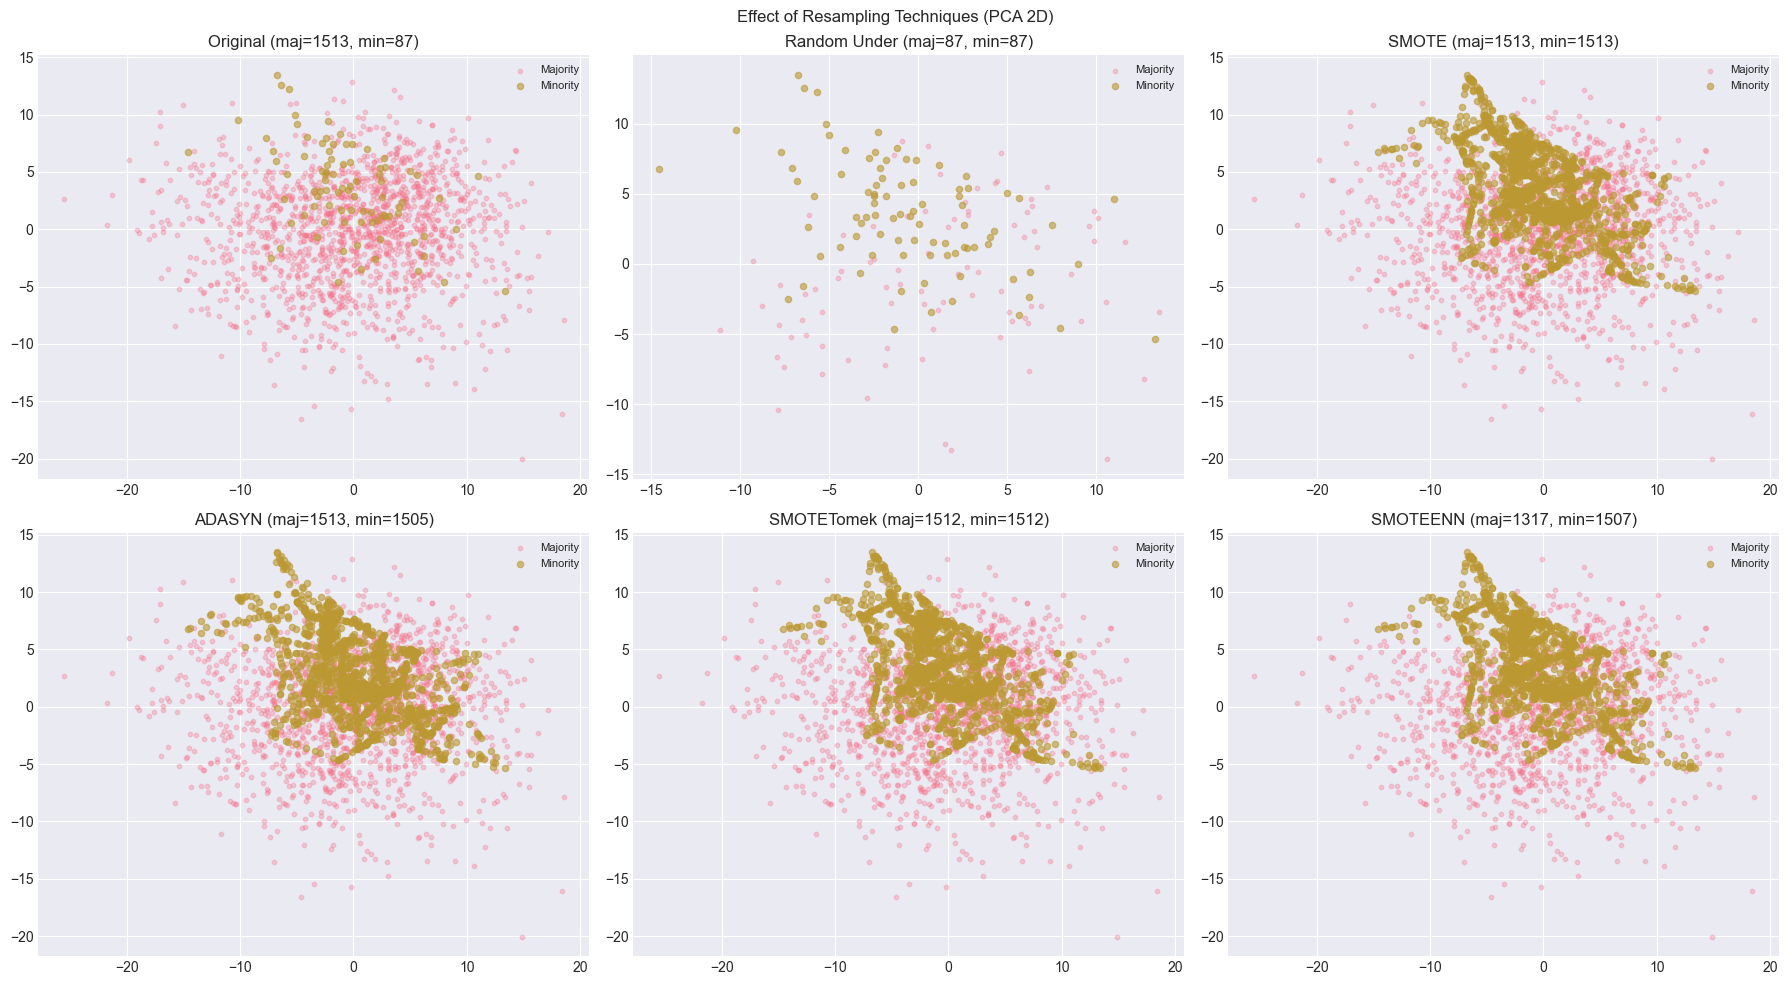

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(Xi_tr)

methods_to_plot = {
    'Original': (X_2d, yi_tr),
    'Random Under': RandomUnderSampler(random_state=42).fit_resample(Xi_tr, yi_tr),
    'SMOTE': SMOTE(random_state=42).fit_resample(Xi_tr, yi_tr),
    'ADASYN': ADASYN(random_state=42).fit_resample(Xi_tr, yi_tr),
    'SMOTETomek': SMOTETomek(random_state=42).fit_resample(Xi_tr, yi_tr),
    'SMOTEENN': SMOTEENN(random_state=42).fit_resample(Xi_tr, yi_tr),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (name, data) in zip(axes.flat, methods_to_plot.items()):
    if name == 'Original':
        X_plot, y_plot = data
    else:
        X_plot = pca.transform(data[0])
        y_plot = data[1]
    ax.scatter(X_plot[y_plot==0, 0], X_plot[y_plot==0, 1], alpha=0.3, s=10, label='Majority')
    ax.scatter(X_plot[y_plot==1, 0], X_plot[y_plot==1, 1], alpha=0.6, s=20, label='Minority')
    ax.set_title(f"{name} (maj={np.sum(y_plot==0)}, min={np.sum(y_plot==1)})")
    ax.legend(fontsize=8)

plt.suptitle('Effect of Resampling Techniques (PCA 2D)')
plt.tight_layout()
plt.show()

## 5.7 Proper Pipeline with Resampling (imblearn Pipeline)

Use `imblearn.pipeline.Pipeline` instead of `sklearn.pipeline.Pipeline` for resampling steps.

In [53]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    'No resampling': ImbPipeline([('scl', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'Class weights': ImbPipeline([('scl', StandardScaler()), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))]),
    'Random Under': ImbPipeline([('smp', RandomUnderSampler(random_state=42)), ('scl', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'SMOTE': ImbPipeline([('smp', SMOTE(random_state=42)), ('scl', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'SMOTETomek': ImbPipeline([('smp', SMOTETomek(random_state=42)), ('scl', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'SMOTEENN': ImbPipeline([('smp', SMOTEENN(random_state=42)), ('scl', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
}

print(f"{'Method':<20} {'CV F1 (macro)':>15} {'Std':>8}")
print("-" * 47)
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, Xi_tr, yi_tr, cv=cv, scoring='f1_macro')
    print(f"{name:<20} {scores.mean():>15.4f} {scores.std():>8.4f}")

Method                 CV F1 (macro)      Std
-----------------------------------------------
No resampling                 0.6612   0.0289
Class weights                 0.6181   0.0268
Random Under                  0.5771   0.0323
SMOTE                         0.6282   0.0178
SMOTETomek                    0.6282   0.0178
SMOTEENN                      0.6065   0.0171


# 6. Ensemble Methods

Ensemble methods combine multiple weak models to improve performance:
1. **Bagging**: Bootstrap aggregating (e.g. Random Forest)
2. **Stacking**: A meta-learner combines outputs of base models
3. **Boosting**: Sequential combination of weak learners (AdaBoost, XGBoost, etc.)
4. **Voting**: Majority vote or averaging from multiple models

## 6.1 Bagging

In [54]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score

cancer = load_breast_cancer()
Xe_tr, Xe_te, ye_tr, ye_te = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=42, stratify=cancer.target)
sc_e = StandardScaler()
Xe_tr_s = sc_e.fit_transform(Xe_tr)
Xe_te_s = sc_e.transform(Xe_te)

bagging_models = {
    'Single DecisionTree': DecisionTreeClassifier(random_state=42),
    'BaggingClassifier (10 trees)': BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10, random_state=42),
    'BaggingClassifier (50 trees)': BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42),
    'RandomForest (100 trees)': RandomForestClassifier(n_estimators=100, random_state=42),
    'ExtraTrees (100 trees)': ExtraTreesClassifier(n_estimators=100, random_state=42),
}

print(f"{'Model':<35} {'CV Accuracy':>12} {'Std':>8}")
print("-" * 58)
for name, model in bagging_models.items():
    scores = cross_val_score(model, Xe_tr_s, ye_tr, cv=5, scoring='accuracy')
    print(f"{name:<35} {scores.mean():>12.4f} {scores.std():>8.4f}")

Model                                CV Accuracy      Std
----------------------------------------------------------
Single DecisionTree                       0.9099   0.0189
BaggingClassifier (10 trees)              0.9341   0.0241
BaggingClassifier (50 trees)              0.9538   0.0189
RandomForest (100 trees)                  0.9538   0.0235
ExtraTrees (100 trees)                    0.9714   0.0256


## 6.2 Stacking

A meta-learner is trained to combine predictions of base models.

In [55]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Define base estimators
base_estimators = [
    ('lr', LogisticRegression(max_iter=5000, random_state=42)),
    ('svc', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('nb', GaussianNB()),
]

# Stacking with Logistic Regression as meta-learner
stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=5000, random_state=42),
    cv=5
)

scores = cross_val_score(stacking, Xe_tr_s, ye_tr, cv=5, scoring='accuracy')
print(f"Stacking (5 base + LR meta): CV Accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Compare with individual models
for name, model in base_estimators:
    scores_i = cross_val_score(model, Xe_tr_s, ye_tr, cv=5, scoring='accuracy')
    print(f"  {name}: {scores_i.mean():.4f} (+/- {scores_i.std():.4f})")

Stacking (5 base + LR meta): CV Accuracy = 0.9780 (+/- 0.0231)
  lr: 0.9802 (+/- 0.0128)
  svc: 0.9714 (+/- 0.0179)
  knn: 0.9670 (+/- 0.0209)
  dt: 0.9319 (+/- 0.0213)
  nb: 0.9319 (+/- 0.0044)


## 6.3 Voting

Combine predictions via hard voting (majority) or soft voting (averaged probabilities).

In [56]:
from sklearn.ensemble import VotingClassifier

# Hard voting
voting_hard = VotingClassifier(
    estimators=base_estimators,
    voting='hard'
)

# Soft voting (requires probability support)
voting_soft = VotingClassifier(
    estimators=base_estimators,
    voting='soft'
)

# Weighted soft voting
voting_weighted = VotingClassifier(
    estimators=base_estimators,
    voting='soft',
    weights=[2, 1, 1, 1, 1]  # give more weight to LogisticRegression
)

for name, voter in [('Hard voting', voting_hard), ('Soft voting', voting_soft), ('Weighted soft', voting_weighted)]:
    scores = cross_val_score(voter, Xe_tr_s, ye_tr, cv=5, scoring='accuracy')
    print(f"{name:<20}: CV Accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

Hard voting         : CV Accuracy = 0.9736 (+/- 0.0204)
Soft voting         : CV Accuracy = 0.9648 (+/- 0.0146)
Weighted soft       : CV Accuracy = 0.9714 (+/- 0.0192)


## 6.4 Boosting (Preview)

Boosting algorithms sequentially combine weak learners, focusing on misclassified examples.
Full coverage in Machine Learning in Finance II, but here is a quick comparison.

In [57]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

boosting_models = {
    'AdaBoost (50 estimators)': AdaBoostClassifier(n_estimators=50, random_state=42),
    'AdaBoost (100 estimators)': AdaBoostClassifier(n_estimators=100, random_state=42),
    'GradientBoosting (100)': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'GradientBoosting (200)': GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42),
}

print(f"{'Model':<35} {'CV Accuracy':>12} {'Std':>8}")
print("-" * 58)
for name, model in boosting_models.items():
    scores = cross_val_score(model, Xe_tr_s, ye_tr, cv=5, scoring='accuracy')
    print(f"{name:<35} {scores.mean():>12.4f} {scores.std():>8.4f}")

Model                                CV Accuracy      Std
----------------------------------------------------------
AdaBoost (50 estimators)                  0.9692   0.0245
AdaBoost (100 estimators)                 0.9736   0.0215
GradientBoosting (100)                    0.9560   0.0139
GradientBoosting (200)                    0.9648   0.0128


## 6.5 Ensemble Comparison Summary

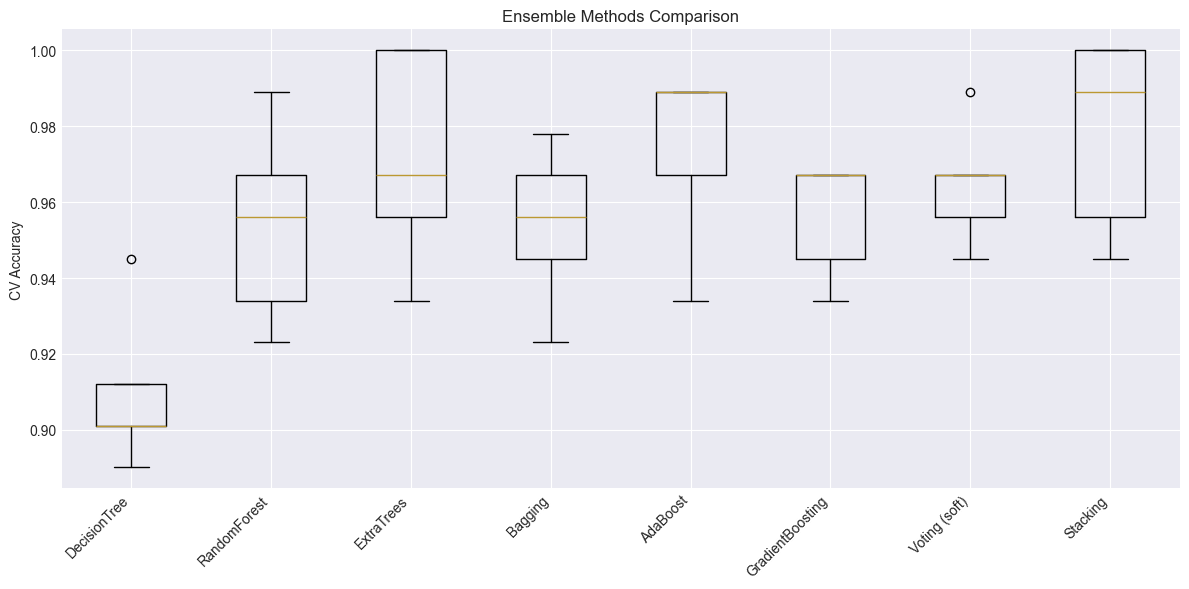

In [58]:
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier,
    BaggingClassifier, StackingClassifier, VotingClassifier
)

all_models = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'Bagging': BaggingClassifier(n_estimators=50, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Voting (soft)': voting_soft,
    'Stacking': stacking,
}

results = {}
for name, model in all_models.items():
    scores = cross_val_score(model, Xe_tr_s, ye_tr, cv=5, scoring='accuracy')
    results[name] = scores

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(results.values(), labels=results.keys())
ax.set_ylabel('CV Accuracy')
ax.set_title('Ensemble Methods Comparison')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 7. Probability Calibration

Probability calibration allows to:
1. Better calibrate probabilities of a classification model
2. Add probability support for models that don't return it natively (e.g. SVM)

**Well calibrated classifiers**: the output probability can be directly interpreted as a confidence level.

Useful in credit risk, insurance, and any domain where correctly estimated probabilities matter.

## 7.1 Calibration Curves (Reliability Diagrams)

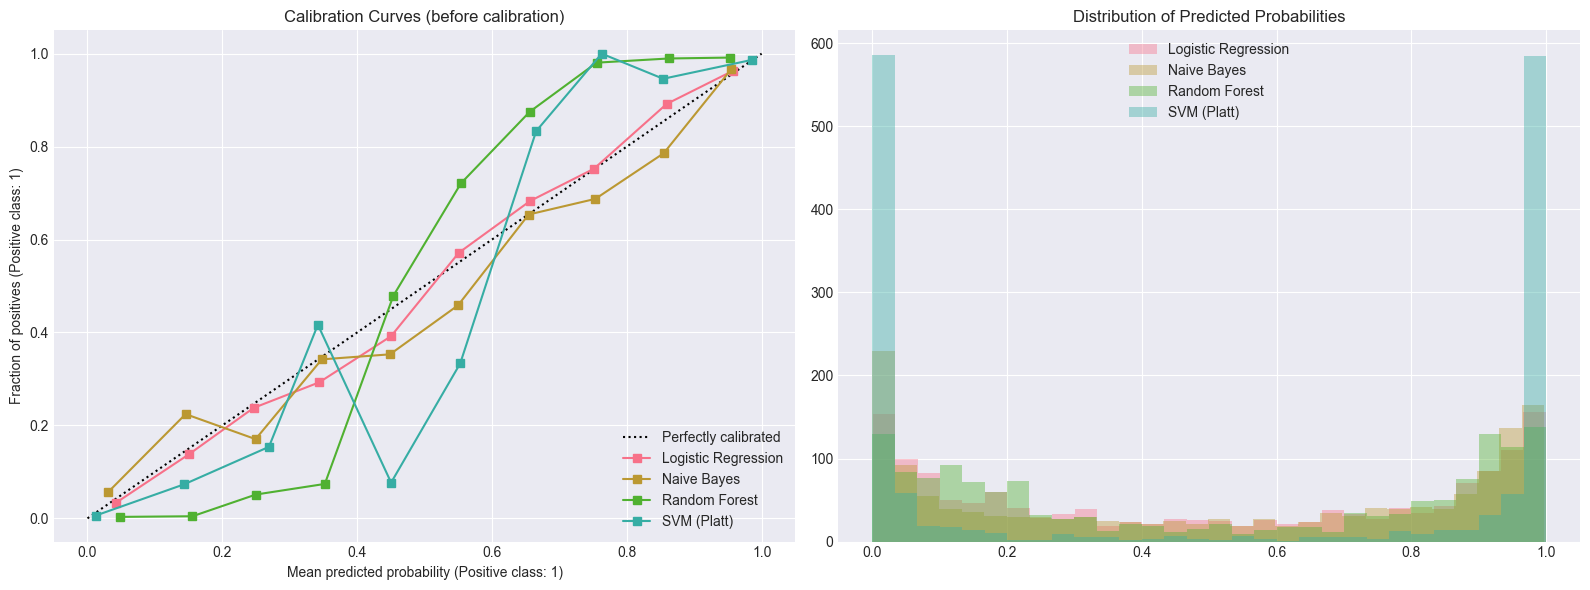

In [59]:
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV, calibration_curve
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

X_cal, y_cal = make_classification(n_samples=5000, n_features=20, n_informative=10, random_state=42)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_cal, y_cal, test_size=0.3, random_state=42, stratify=y_cal)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (Platt)': SVC(probability=True, random_state=42),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, model in models.items():
    model.fit(Xc_tr, yc_tr)
    CalibrationDisplay.from_estimator(model, Xc_te, yc_te, n_bins=10, name=name, ax=axes[0])

axes[0].set_title('Calibration Curves (before calibration)')

# Show distribution of predicted probabilities
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(Xc_te)[:, 1]
    else:
        probs = model.decision_function(Xc_te)
    axes[1].hist(probs, bins=30, alpha=0.4, label=name)
axes[1].set_title('Distribution of Predicted Probabilities')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7.2 Calibrating Models

Calibration fits a regressor (calibrator) that maps model output to calibrated probabilities in [0, 1].

**Important**: must be done via cross-validation to avoid bias.

Two calibration methods:
- **Sigmoid** (Platt scaling): fits $p = 1/(1 + \exp(Af + B))$ — best when model is under-confident
- **Isotonic**: non-parametric monotone fit — more powerful but prone to overfitting (needs >1000 samples)

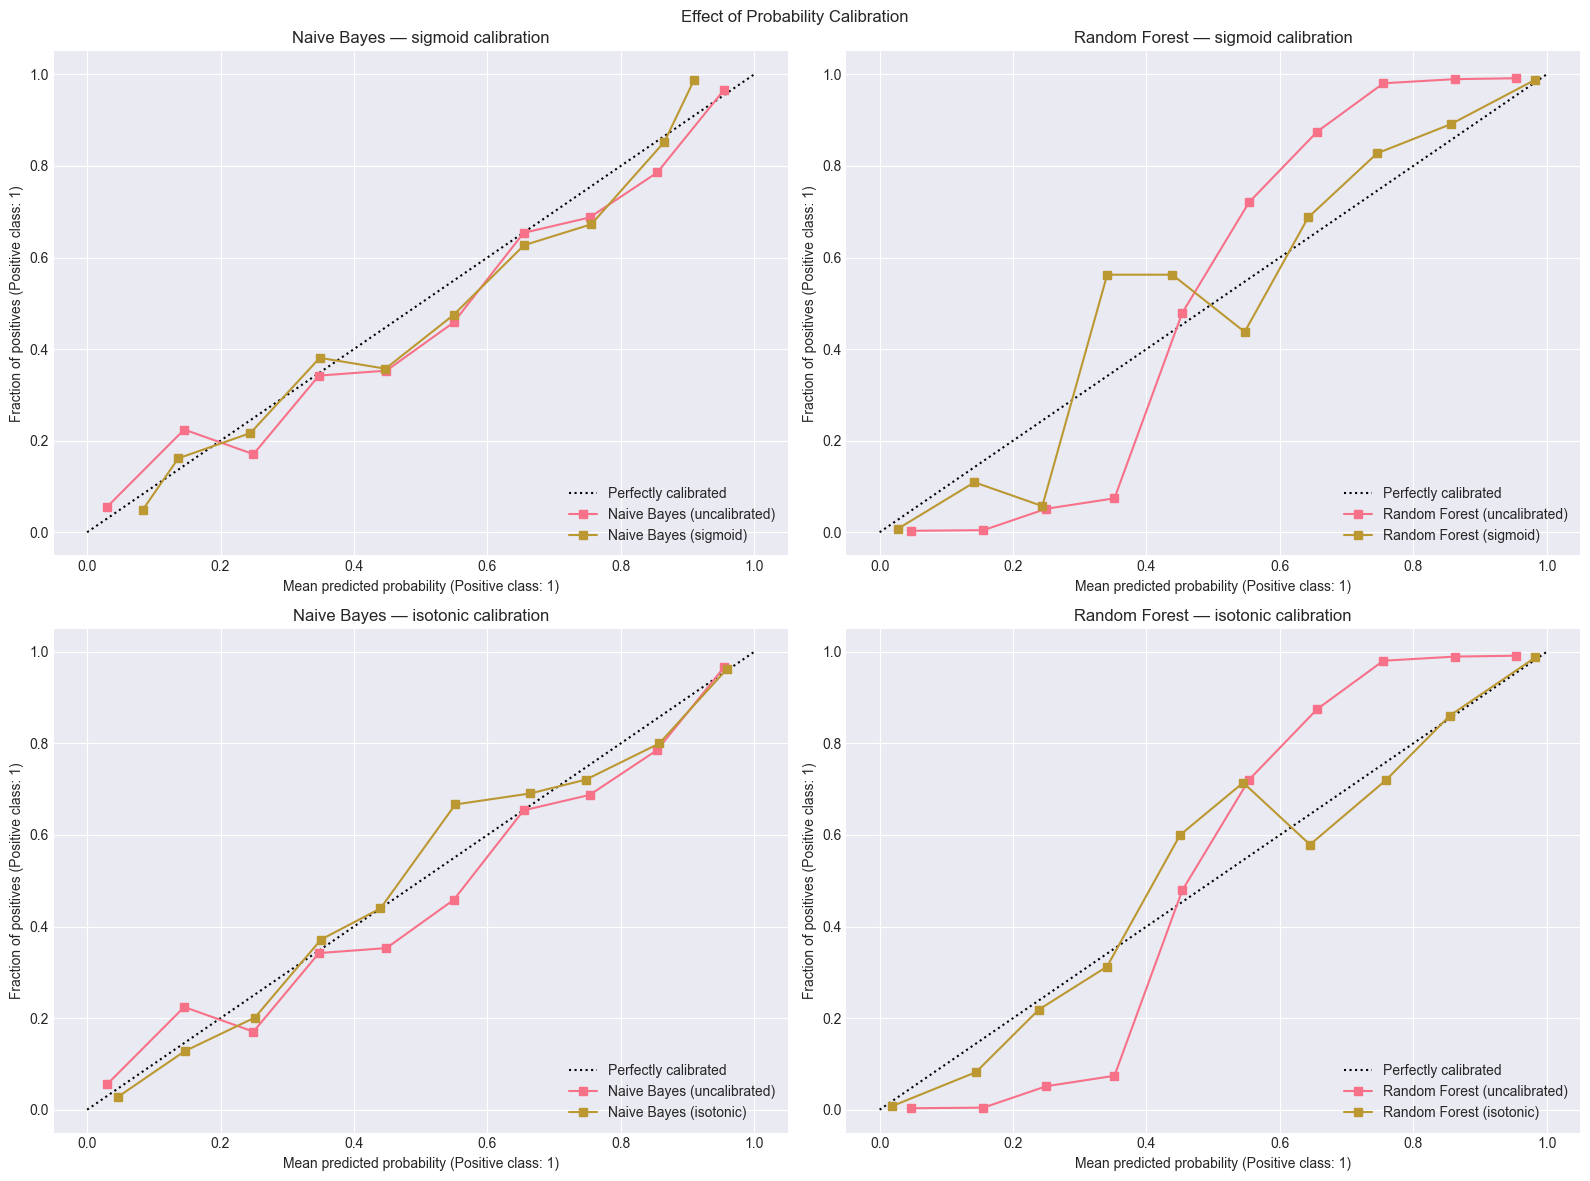

In [60]:
# Calibrate each model with sigmoid and isotonic methods
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax_row, method in zip(axes, ['sigmoid', 'isotonic']):
    for ax, (name, model_cls) in zip(ax_row, [
        ('Naive Bayes', GaussianNB()),
        ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ]):
        # Uncalibrated
        model_cls.fit(Xc_tr, yc_tr)
        CalibrationDisplay.from_estimator(model_cls, Xc_te, yc_te, n_bins=10, name=f'{name} (uncalibrated)', ax=ax)

        # Calibrated
        calibrated = CalibratedClassifierCV(model_cls, method=method, cv=5)
        calibrated.fit(Xc_tr, yc_tr)
        CalibrationDisplay.from_estimator(calibrated, Xc_te, yc_te, n_bins=10, name=f'{name} ({method})', ax=ax)

        ax.set_title(f'{name} — {method} calibration')

plt.suptitle('Effect of Probability Calibration')
plt.tight_layout()
plt.show()

## 7.3 Brier Score

The Brier score measures the quality of calibration (lower is better):
$$BS = \frac{1}{N} \sum_{i=1}^{N} (p_i - y_i)^2$$

In [61]:
from sklearn.metrics import brier_score_loss, log_loss

print(f"{'Model':<35} {'Brier (uncal)':>14} {'Brier (sig)':>12} {'Brier (iso)':>12}")
print("-" * 78)

for name, model_cls in [
    ('LogisticRegression', LogisticRegression(max_iter=1000, random_state=42)),
    ('GaussianNB', GaussianNB()),
    ('RandomForest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('SVC', SVC(random_state=42)),
]:
    # Uncalibrated
    model_cls.fit(Xc_tr, yc_tr)
    if hasattr(model_cls, 'predict_proba'):
        p_uncal = model_cls.predict_proba(Xc_te)[:, 1]
        bs_uncal = brier_score_loss(yc_te, p_uncal)
    else:
        bs_uncal = float('nan')

    # Sigmoid calibration
    cal_sig = CalibratedClassifierCV(model_cls, method='sigmoid', cv=5)
    cal_sig.fit(Xc_tr, yc_tr)
    p_sig = cal_sig.predict_proba(Xc_te)[:, 1]
    bs_sig = brier_score_loss(yc_te, p_sig)

    # Isotonic calibration
    cal_iso = CalibratedClassifierCV(model_cls, method='isotonic', cv=5)
    cal_iso.fit(Xc_tr, yc_tr)
    p_iso = cal_iso.predict_proba(Xc_te)[:, 1]
    bs_iso = brier_score_loss(yc_te, p_iso)

    print(f"{name:<35} {bs_uncal:>14.6f} {bs_sig:>12.6f} {bs_iso:>12.6f}")

Model                                Brier (uncal)  Brier (sig)  Brier (iso)
------------------------------------------------------------------------------
LogisticRegression                        0.108795     0.108942     0.108958
GaussianNB                                0.120959     0.122261     0.120607
RandomForest                              0.047873     0.031286     0.031558
SVC                                            nan     0.022635     0.021385


## 7.4 Calibration in a Pipeline

In [62]:
from sklearn.pipeline import Pipeline

# SVM doesn't return probabilities by default - calibration adds this capability
pipe_svm_calibrated = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', CalibratedClassifierCV(SVC(random_state=42), method='sigmoid', cv=5)),
])

pipe_svm_calibrated.fit(Xc_tr, yc_tr)
probs = pipe_svm_calibrated.predict_proba(Xc_te)
print(f"SVM with calibration - predict_proba shape: {probs.shape}")
print(f"Sample predictions: {probs[:5].round(4)}")
print(f"Brier score: {brier_score_loss(yc_te, probs[:, 1]):.6f}")

SVM with calibration - predict_proba shape: (1500, 2)
Sample predictions: [[3.171e-01 6.829e-01]
 [1.953e-01 8.047e-01]
 [1.700e-02 9.830e-01]
 [9.892e-01 1.080e-02]
 [5.000e-04 9.995e-01]]
Brier score: 0.030852


# 8. Model Depreciation — Pattern Change in ML

Models degrade over time as data distributions and relationships change. Three types of drift:

| Drift Type | Description | Features-Target Dynamics |
|-----------|-------------|-------------------------|
| **Data Drift** | Change in distribution of input features | Remains the same |
| **Concept Drift** | Change in relationship between features and target | Changes over time |
| **Covariate Drift** | Change in distribution of *some* input features | Remains the same |

**Examples**:
- Data drift: shift in house size distribution, changes in transaction amounts
- Concept drift: spam characteristics evolve, new fraud patterns, new money laundering techniques
- Covariate drift: shift in customer age distribution in churn prediction

## 8.1 Simulating and Detecting Data Drift

In [63]:
from scipy.stats import ks_2samp, wasserstein_distance

# Simulate data drift: training data vs shifted "production" data
np.random.seed(42)
X_reference = np.random.normal(0, 1, (1000, 5))
X_drifted = np.random.normal(0.5, 1.2, (1000, 5))  # shifted mean and variance
X_no_drift = np.random.normal(0.02, 1.01, (1000, 5))  # nearly identical

feature_names_drift = [f'Feature_{i}' for i in range(5)]

print("=== Drift Detection: KS Test ===")
print(f"{'Feature':<15} {'Drifted (stat)':>15} {'p-value':>10} {'No-drift (stat)':>16} {'p-value':>10}")
print("-" * 70)
for i, name in enumerate(feature_names_drift):
    stat_d, p_d = ks_2samp(X_reference[:, i], X_drifted[:, i])
    stat_n, p_n = ks_2samp(X_reference[:, i], X_no_drift[:, i])
    print(f"{name:<15} {stat_d:>15.4f} {p_d:>10.6f} {stat_n:>16.4f} {p_n:>10.6f}")

=== Drift Detection: KS Test ===
Feature          Drifted (stat)    p-value  No-drift (stat)    p-value
----------------------------------------------------------------------
Feature_0                0.2020   0.000000           0.0500   0.164114
Feature_1                0.2150   0.000000           0.0680   0.019602
Feature_2                0.1900   0.000000           0.0440   0.287798
Feature_3                0.1710   0.000000           0.0350   0.572890
Feature_4                0.2000   0.000000           0.0270   0.859545


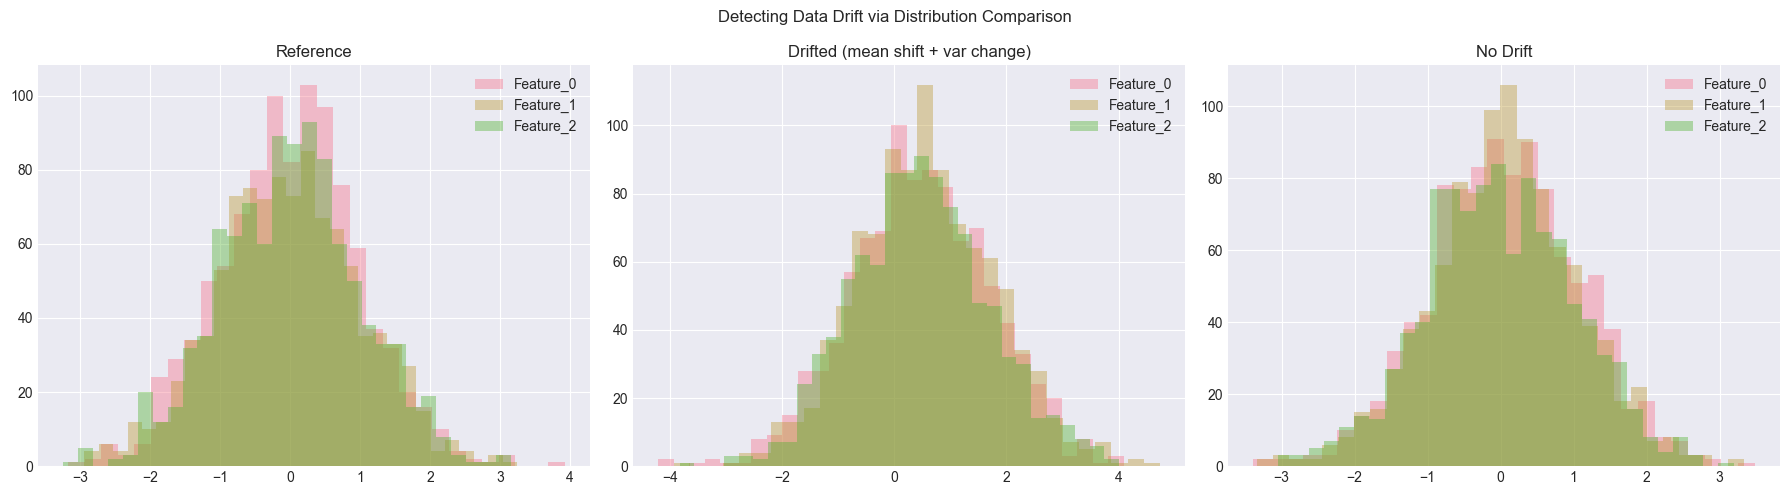

In [64]:
# Visualize distribution drift
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, data) in zip(axes, [
    ('Reference', X_reference),
    ('Drifted (mean shift + var change)', X_drifted),
    ('No Drift', X_no_drift),
]):
    for i in range(min(3, data.shape[1])):
        ax.hist(data[:, i], bins=30, alpha=0.4, label=feature_names_drift[i])
    ax.set_title(title)
    ax.legend()

plt.suptitle('Detecting Data Drift via Distribution Comparison')
plt.tight_layout()
plt.show()

## 8.2 Simulating Concept Drift

In [65]:
# Simulate concept drift: relationship between X and y changes over time
np.random.seed(42)

# Period 1: y = 2*x1 + 3*x2 + noise
X_p1 = np.random.normal(0, 1, (500, 2))
y_p1 = 2 * X_p1[:, 0] + 3 * X_p1[:, 1] + np.random.normal(0, 0.5, 500)

# Period 2: y = -1*x1 + 5*x2 + noise (relationship changed!)
X_p2 = np.random.normal(0, 1, (500, 2))
y_p2 = -1 * X_p2[:, 0] + 5 * X_p2[:, 1] + np.random.normal(0, 0.5, 500)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train on period 1, test on period 1 vs period 2
model_p1 = LinearRegression().fit(X_p1, y_p1)

pred_p1 = model_p1.predict(X_p1)
pred_p2 = model_p1.predict(X_p2)

print("Model trained on Period 1:")
print(f"  Coefficients: {model_p1.coef_.round(4)}")
print(f"  Period 1 R2: {r2_score(y_p1, pred_p1):.4f}, MSE: {mean_squared_error(y_p1, pred_p1):.4f}")
print(f"  Period 2 R2: {r2_score(y_p2, pred_p2):.4f}, MSE: {mean_squared_error(y_p2, pred_p2):.4f}")
print("  -> Concept drift causes severe performance degradation!")

# Retrained model on period 2
model_p2 = LinearRegression().fit(X_p2, y_p2)
print(f"\nRetrained on Period 2:")
print(f"  Coefficients: {model_p2.coef_.round(4)}")
print(f"  Period 2 R2: {r2_score(y_p2, model_p2.predict(X_p2)):.4f}")

Model trained on Period 1:
  Coefficients: [2.004  3.0303]
  Period 1 R2: 0.9800, MSE: 0.2537
  Period 2 R2: 0.5044, MSE: 11.9919
  -> Concept drift causes severe performance degradation!

Retrained on Period 2:
  Coefficients: [-0.9958  5.0034]
  Period 2 R2: 0.9895


## 8.3 Monitoring Model Performance Over Time

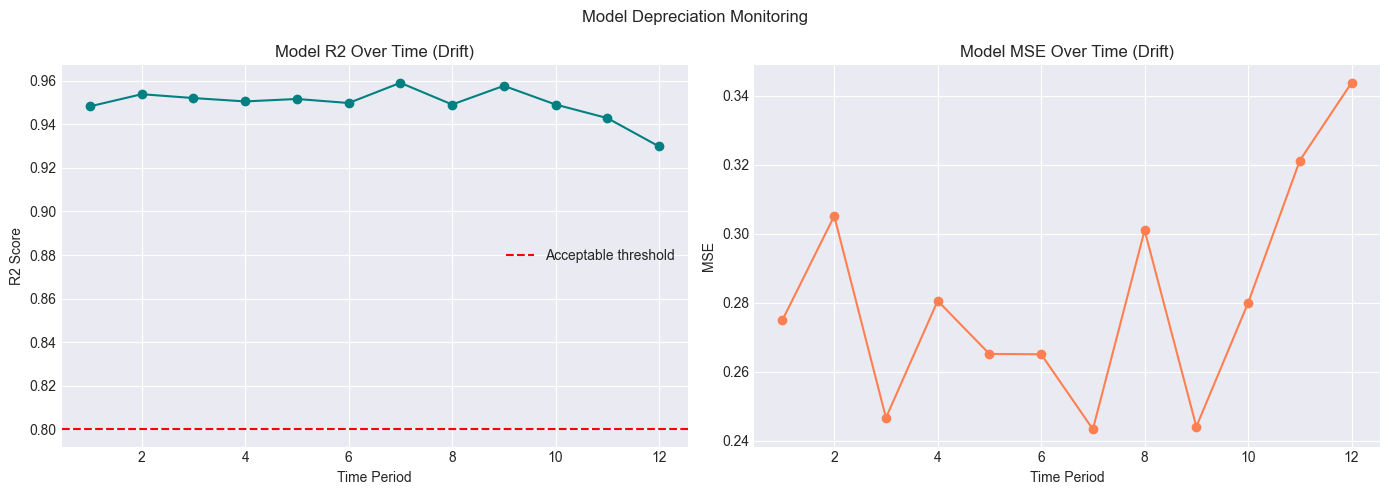

In [66]:
# Simulate model performance degradation over time
np.random.seed(42)
n_periods = 12
train_data = np.random.normal(0, 1, (1000, 5))
train_target = 2 * train_data[:, 0] - train_data[:, 1] + np.random.normal(0, 0.5, 1000)

model_monitor = LinearRegression().fit(train_data, train_target)

performances = []
for period in range(n_periods):
    drift = period * 0.1  # gradually increasing drift
    test_data = np.random.normal(drift, 1 + drift * 0.1, (200, 5))
    # Also gradually shift the relationship
    test_target = (2 - drift * 0.15) * test_data[:, 0] - test_data[:, 1] + np.random.normal(0, 0.5, 200)
    r2 = r2_score(test_target, model_monitor.predict(test_data))
    mse = mean_squared_error(test_target, model_monitor.predict(test_data))
    performances.append({'Period': period + 1, 'R2': r2, 'MSE': mse})

perf_df = pd.DataFrame(performances)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(perf_df['Period'], perf_df['R2'], 'o-', color='teal')
axes[0].axhline(y=0.8, color='red', linestyle='--', label='Acceptable threshold')
axes[0].set_xlabel('Time Period')
axes[0].set_ylabel('R2 Score')
axes[0].set_title('Model R2 Over Time (Drift)')
axes[0].legend()

axes[1].plot(perf_df['Period'], perf_df['MSE'], 'o-', color='coral')
axes[1].set_xlabel('Time Period')
axes[1].set_ylabel('MSE')
axes[1].set_title('Model MSE Over Time (Drift)')

plt.suptitle('Model Depreciation Monitoring')
plt.tight_layout()
plt.show()

## 8.4 Wasserstein Distance for Drift Detection

In [67]:
from scipy.stats import wasserstein_distance

print("=== Wasserstein Distance ===")
print(f"{'Feature':<15} {'Drifted':>10} {'No-drift':>10}")
print("-" * 38)
for i, name in enumerate(feature_names_drift):
    w_d = wasserstein_distance(X_reference[:, i], X_drifted[:, i])
    w_n = wasserstein_distance(X_reference[:, i], X_no_drift[:, i])
    print(f"{name:<15} {w_d:>10.4f} {w_n:>10.4f}")

print("\nLarger Wasserstein distance = more drift")

=== Wasserstein Distance ===
Feature            Drifted   No-drift
--------------------------------------
Feature_0           0.4884     0.0734
Feature_1           0.5742     0.0776
Feature_2           0.4710     0.0424
Feature_3           0.4153     0.0505
Feature_4           0.4901     0.0363

Larger Wasserstein distance = more drift


# Summary

| Chapter | Key sklearn/imblearn Classes |
|---------|----------------------------|
| **1. Imputation** | `SimpleImputer`, `KNNImputer`, `IterativeImputer`, `MissingIndicator` |
| **2. Feature Engineering** | `MinMaxScaler`, `StandardScaler`, `RobustScaler`, `QuantileTransformer`, `PowerTransformer`, `KBinsDiscretizer`, `PolynomialFeatures`, `SplineTransformer`, `OneHotEncoder`, `OrdinalEncoder`, `TargetEncoder`, `LabelEncoder`, `ColumnTransformer` |
| **3. Regularization** | `Ridge`, `Lasso`, `ElasticNet`, `RidgeCV`, `LassoCV`, `ElasticNetCV`, `LogisticRegression(penalty=...)`, `SGDClassifier` |
| **4. Feature Selection** | `VarianceThreshold`, `SelectKBest`, `SelectPercentile`, `f_classif`, `chi2`, `mutual_info_classif`, `RFE`, `RFECV`, `SequentialFeatureSelector`, `SelectFromModel`, `permutation_importance` |
| **5. Rebalancing** | `RandomUnderSampler`, `ClusterCentroids`, `TomekLinks`, `EditedNearestNeighbours`, `RandomOverSampler`, `SMOTE`, `BorderlineSMOTE`, `SVMSMOTE`, `KMeansSMOTE`, `ADASYN`, `SMOTETomek`, `SMOTEENN` |
| **6. Ensemble** | `BaggingClassifier`, `RandomForestClassifier`, `ExtraTreesClassifier`, `AdaBoostClassifier`, `GradientBoostingClassifier`, `StackingClassifier`, `VotingClassifier` |
| **7. Calibration** | `CalibratedClassifierCV`, `CalibrationDisplay`, `calibration_curve`, `brier_score_loss` |
| **8. Drift** | `scipy.stats.ks_2samp`, `scipy.stats.wasserstein_distance` |